In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, PercentFormatter
from matplotlib.ticker import MultipleLocator, MaxNLocator, PercentFormatter
import numpy as np

In [2]:
np.round(np.arange(0.145, 0.2, 0.005), 3)

array([0.145, 0.15 , 0.155, 0.16 , 0.165, 0.17 , 0.175, 0.18 , 0.185,
       0.19 , 0.195, 0.2  ])

In [4]:
def tau_sweep(df, tau_c):
    # ---- (Optional) consistent, print-friendly defaults -------------------------
    plt.rcParams.update({
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "font.size": 10,        # base font
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "pdf.fonttype": 42,     # editable text in vector outputs
        "ps.fonttype": 42,
    })

    # ---- Plot --------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6.2, 4.0))  # column-friendly

    ax.plot(df["beta"], df["SteadyState"], marker="o", linewidth=1.8, markersize=4)

    # Labels & title
    ax.set_xlabel(r"$\tau \; (= \, \beta/\mu, \; \tau)$")
    ax.set_ylabel("Steady-state prevalence")
    ax.set_title(r"Steady state vs. $\tau$")

    # ---- Tick strategy: few clean majors, helpful minors -------------------------
    # Keep ~5–7 readable x ticks automatically; minor ticks for detail
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    # If your steady state is a fraction in [0,1], percent can read better:
    if df["SteadyState"].max() <= 1.05:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    # ---- Grid, spines, and ticks -------------------------------------------------
    ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.35)
    ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.5, alpha=0.25)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(which="both", direction="out", length=5, width=1.2)
    ax.tick_params(which="minor", length=3, width=1.0)

    # ---- (Optional) mark a theoretical threshold tau_c ---------------------------
    ax.axvline(tau_c, linestyle="--", linewidth=1.0)

    ax.text(
        tau_c, 0.01, r"$\tau_c$",
        transform=ax.get_yaxis_transform(),  # x in data coords, y in axes [0..1]
        ha="center", va="bottom"
    )


    # ---- Limits with small padding ----------------------------------------------
    xpad = 0.02 * (df["beta"].max() - df["beta"].min() or 1.0)
    ax.set_xlim(df["beta"].min() - xpad, df["beta"].max() + xpad)

    # Leave y to autoscale; Matplotlib will add a little headroom.

    fig.tight_layout()

    # Save vector + high-dpi raster for paper
    # fig.savefig("tau_vs_steady_state.pdf", bbox_inches="tight")
    # fig.savefig("tau_vs_steady_state.png", dpi=600, bbox_inches="tight")

    plt.show()  # enable if running interactively

In [5]:
def m_sweep(df, m_c):
    # ---- (Optional) consistent, print-friendly defaults -------------------------
    plt.rcParams.update({
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "font.size": 10,        # base font
        "axes.labelsize": 11,   # axis labels
        "axes.titlesize": 11,   # title size
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "pdf.fonttype": 42,     # editable text in vector outputs
        "ps.fonttype": 42,
    })

    # ---- Plot --------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6.2, 4.0))  # compact, column-friendly size

    ax.plot(df["m"], df["SteadyState"], marker="o", linewidth=1.8, markersize=4)

    # Labels & title (adjust wording to match your paper)
    ax.set_xlabel("m (new links per activation)")
    ax.set_ylabel("Steady-state prevalence")     # or "I\u221E" (I∞)
    ax.set_title("Effect of m on steady-state prevalence")

    # ---- Ticks: fewer majors, integer m, optional percent on y -------------------
    # Show major ticks every 5 on x (integers), with light minor ticks each 1
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x):d}")

    if df["SteadyState"].max() <= 1.05:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    # If you want the y-axis in percent, uncomment the next line:
    # ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))

    # Keep y ticks sensible
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, prune=None))

    # ---- Grid & spines -----------------------------------------------------------
    ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.35)
    ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.5, alpha=0.25)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(which="both", direction="out", length=5, width=1.2)
    ax.tick_params(which="minor", length=3, width=1.0)

    # ---- (Optional) mark a theoretical threshold m_c -----------------------------
    m_c = 5   # set your critical value here (if relevant to the figure)
    ax.axvline(m_c, linestyle="--", linewidth=1.0)
    ax.text(m_c, ax.get_ylim()[1]*0.02, r"$m_c$", ha="center", va="bottom")

    # Limits (nice padding without clipping)
    ax.set_xlim(df["m"].min() - 0.5, df["m"].max() + 0.5)

    fig.tight_layout()

    # Save vector + raster for the paper
    # fig.savefig("m_vs_steady_state.pdf", bbox_inches="tight")  # vector (preferred)
    # fig.savefig("m_vs_steady_state.png", dpi=600, bbox_inches="tight")

    plt.show()  # only if you want an interactive preview
    

In [6]:
def HeatMap(df, lambda1, a=0.1):
    # ensure required cols exist
    assert {"m","beta","mu","SteadyState"}.issubset(df.columns), "CSV missing columns."

    # tau = beta/mu
    df["tau"] = df["beta"] / df["mu"]

    # group replicates (if duplicates of (m,tau))
    g = df.groupby(["m","tau"], as_index=False).agg(
        prevalence_mean=("SteadyState","mean"),
        prevalence_se=("SteadyState", lambda x: x.std(ddof=1)/np.sqrt(len(x)))
    )

    # --- heatmap pivot ---
    mat = g.pivot(index="m", columns="tau", values="prevalence_mean")
    mat = mat.sort_index(axis=0).sort_index(axis=1)

    m_vals   = mat.index.values.astype(float)
    tau_vals = mat.columns.values.astype(float)
    Z        = mat.values

    plt.figure(figsize=(8,5))
    im = plt.imshow(Z, origin="lower", aspect="auto",
                    extent=[tau_vals.min(), tau_vals.max(), m_vals.min(), m_vals.max()])
    cbar = plt.colorbar(im)
    cbar.set_label("Steady-state prevalence")

    # theory boundary τc(m) = 1 / (λ1 + 2 a m)
    tau_c = 1.0 / (lambda1 + 2.0*a*m_vals)
    plt.plot(tau_c, m_vals, "w--", lw=2, label=r"Theory: $\tau_c(m)=1/(\lambda_1+2am)$")

    valid_cols = ~np.all(np.isnan(Z), axis=0)
    tau_min, tau_max = tau_vals[valid_cols].min(), tau_vals[valid_cols].max()

    im = plt.imshow(Z, origin="lower", aspect="auto",
                    extent=[tau_min, tau_max, m_vals.min(), m_vals.max()])

    plt.xlabel(r"$\tau=\beta/\mu$")
    plt.ylabel("m (temporal contacts per activation)")
    plt.title("Phase diagram: prevalence over $(\\tau, m)$")
    plt.legend(loc="lower right")
    plt.tight_layout()
    # if save_fig:
    #     plt.savefig("phase_diagram_tau_m.png", dpi=200)
    plt.show()


    # pick up to 5 m-values roughly evenly spaced across what's present
    unique_m = np.sort(g["m"].unique())
    pick = unique_m[np.linspace(0, len(unique_m)-1, 5, dtype=int)]

    plt.figure(figsize=(8,5))
    for m in pick:
        sub = g[g["m"]==m].sort_values("tau")
        plt.plot(sub["tau"], sub["prevalence_mean"], marker="o", label=f"m={int(m)}")
        tau_c_m = 1.0 / (lambda1 + 2.0*a*m)
        plt.axvline(tau_c_m, ls="--", lw=1, color="gray")

    plt.xlabel(r"$\tau$")
    plt.ylabel("Steady-state prevalence")
    plt.title("Cross-sections: prevalence vs $\\tau$ for selected $m$")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("slices_tau_vs_prevalence.png", dpi=200)
    plt.show()


# BA

In [10]:
df = pd.read_csv("BA_HM2.csv")
# df[df['beta'] == 0.12]
df

,Network,m,beta,mu,SteadyState
0,../BA-1000,0,0.090,1,0.0000
1,../BA-1000,0,0.095,1,0.0000
2,../BA-1000,0,0.100,1,0.0000
3,../BA-1000,0,0.105,1,0.0000
4,../BA-1000,0,0.110,1,0.0000
...,...,...,...,...,...
363,../BA-1000,15,0.180,1,0.1887
364,../BA-1000,15,0.185,1,0.1930
365,../BA-1000,15,0.190,1,0.1956
366,../BA-1000,15,0.195,1,0.2130


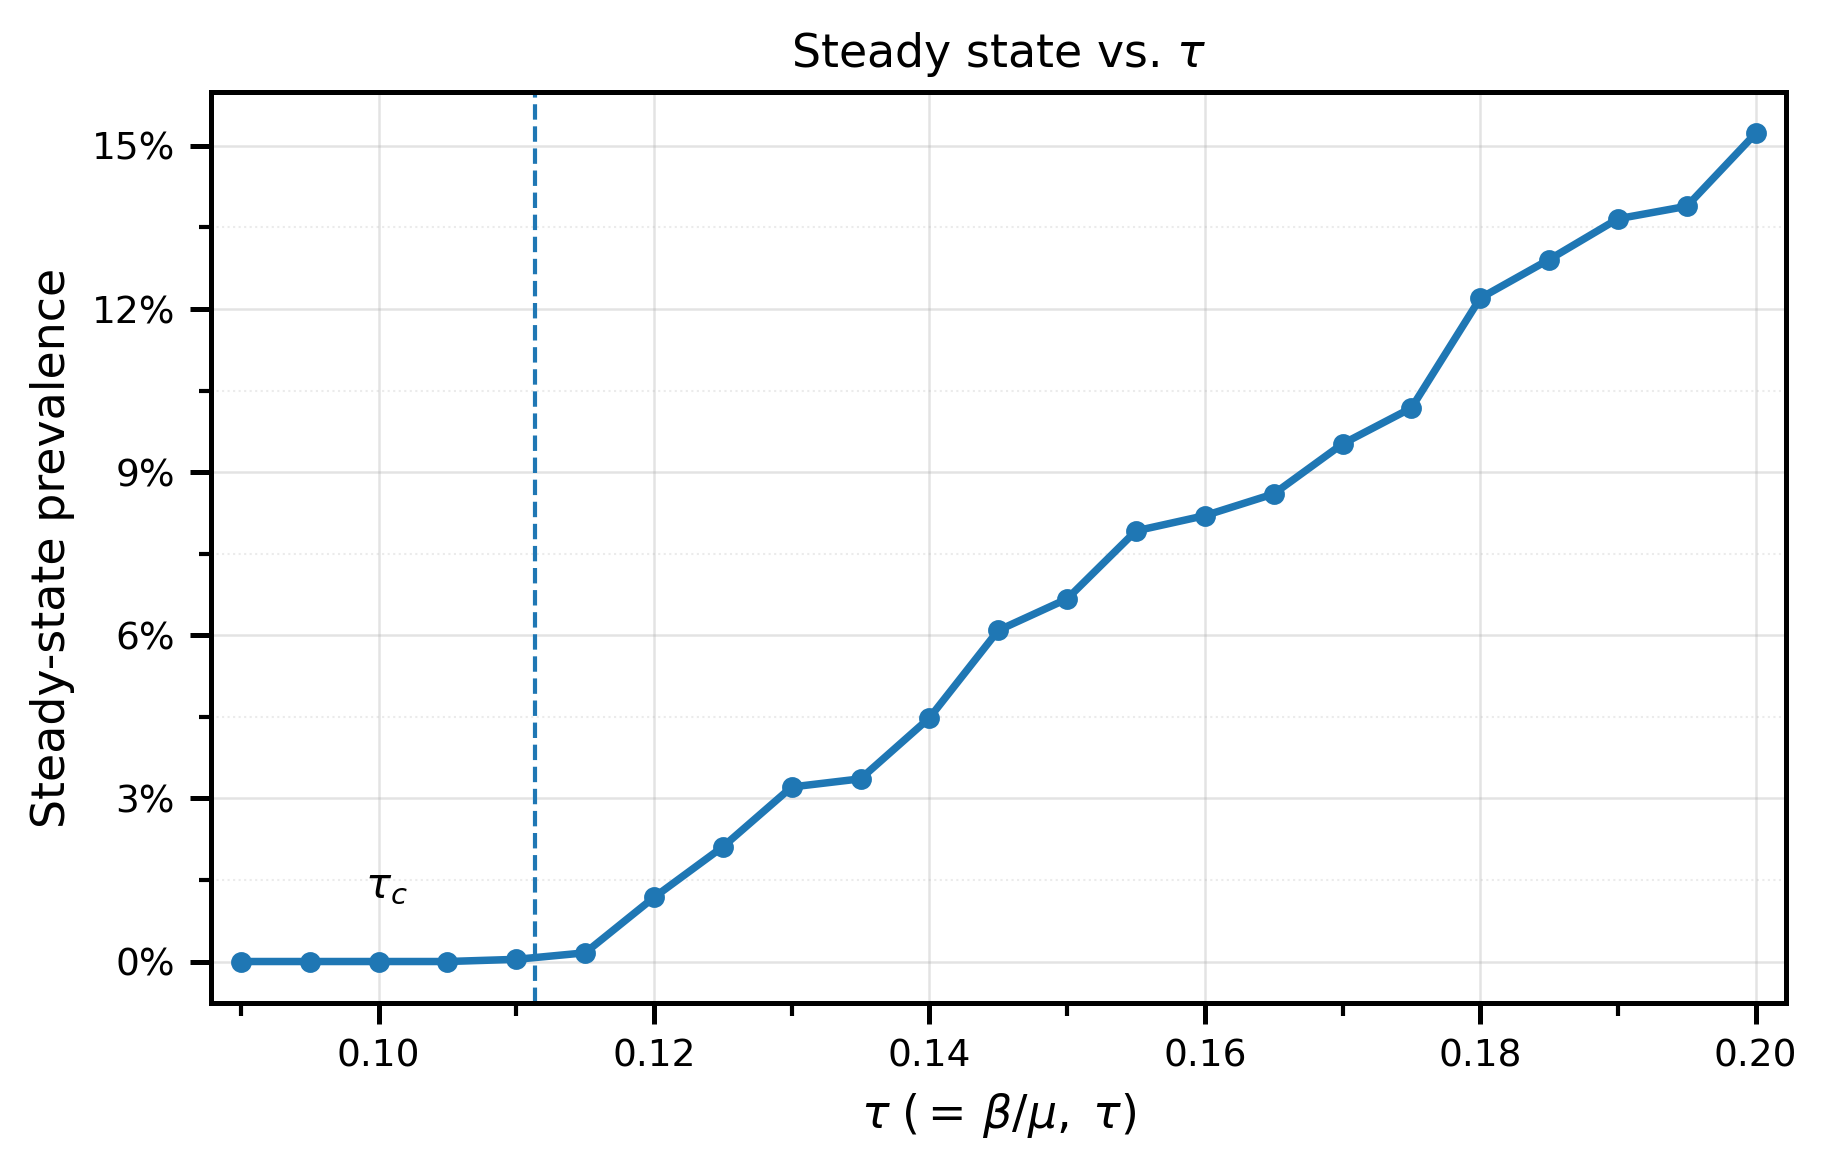

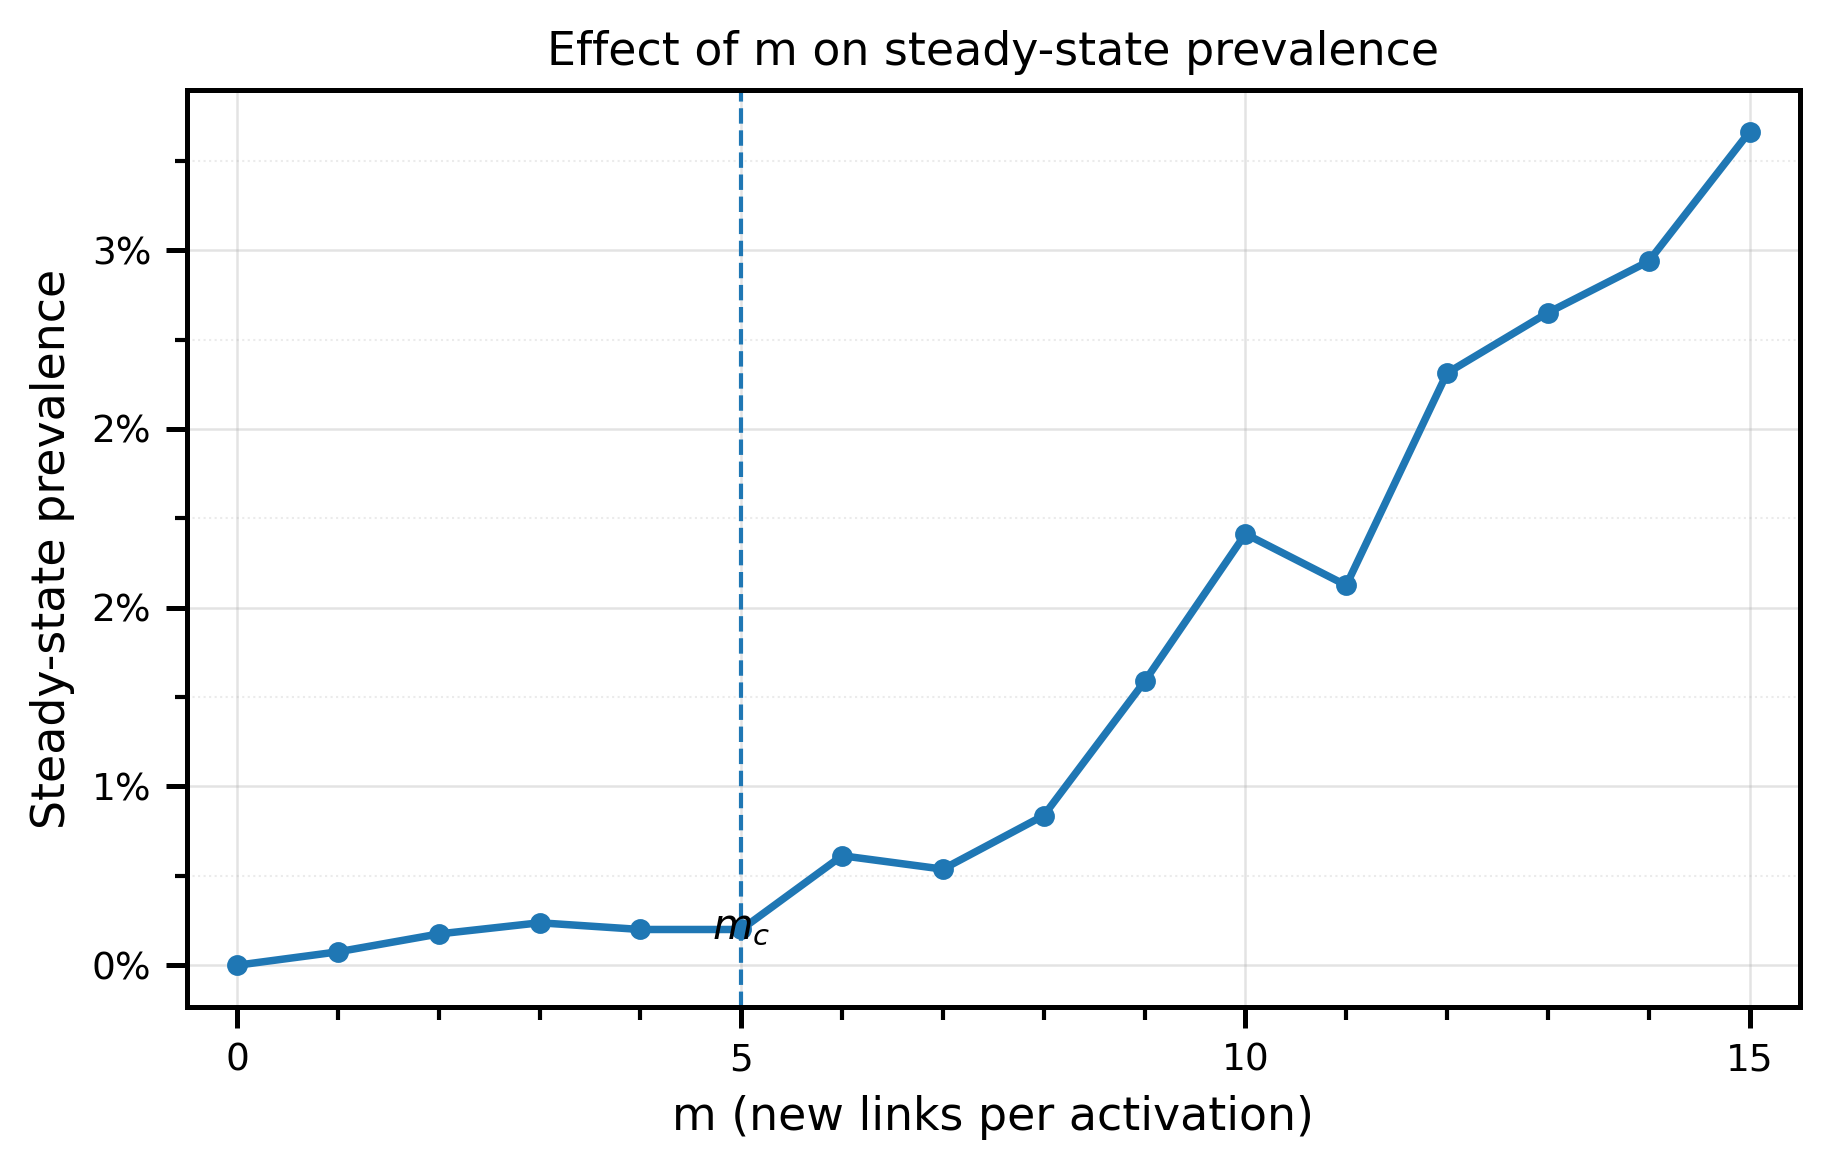

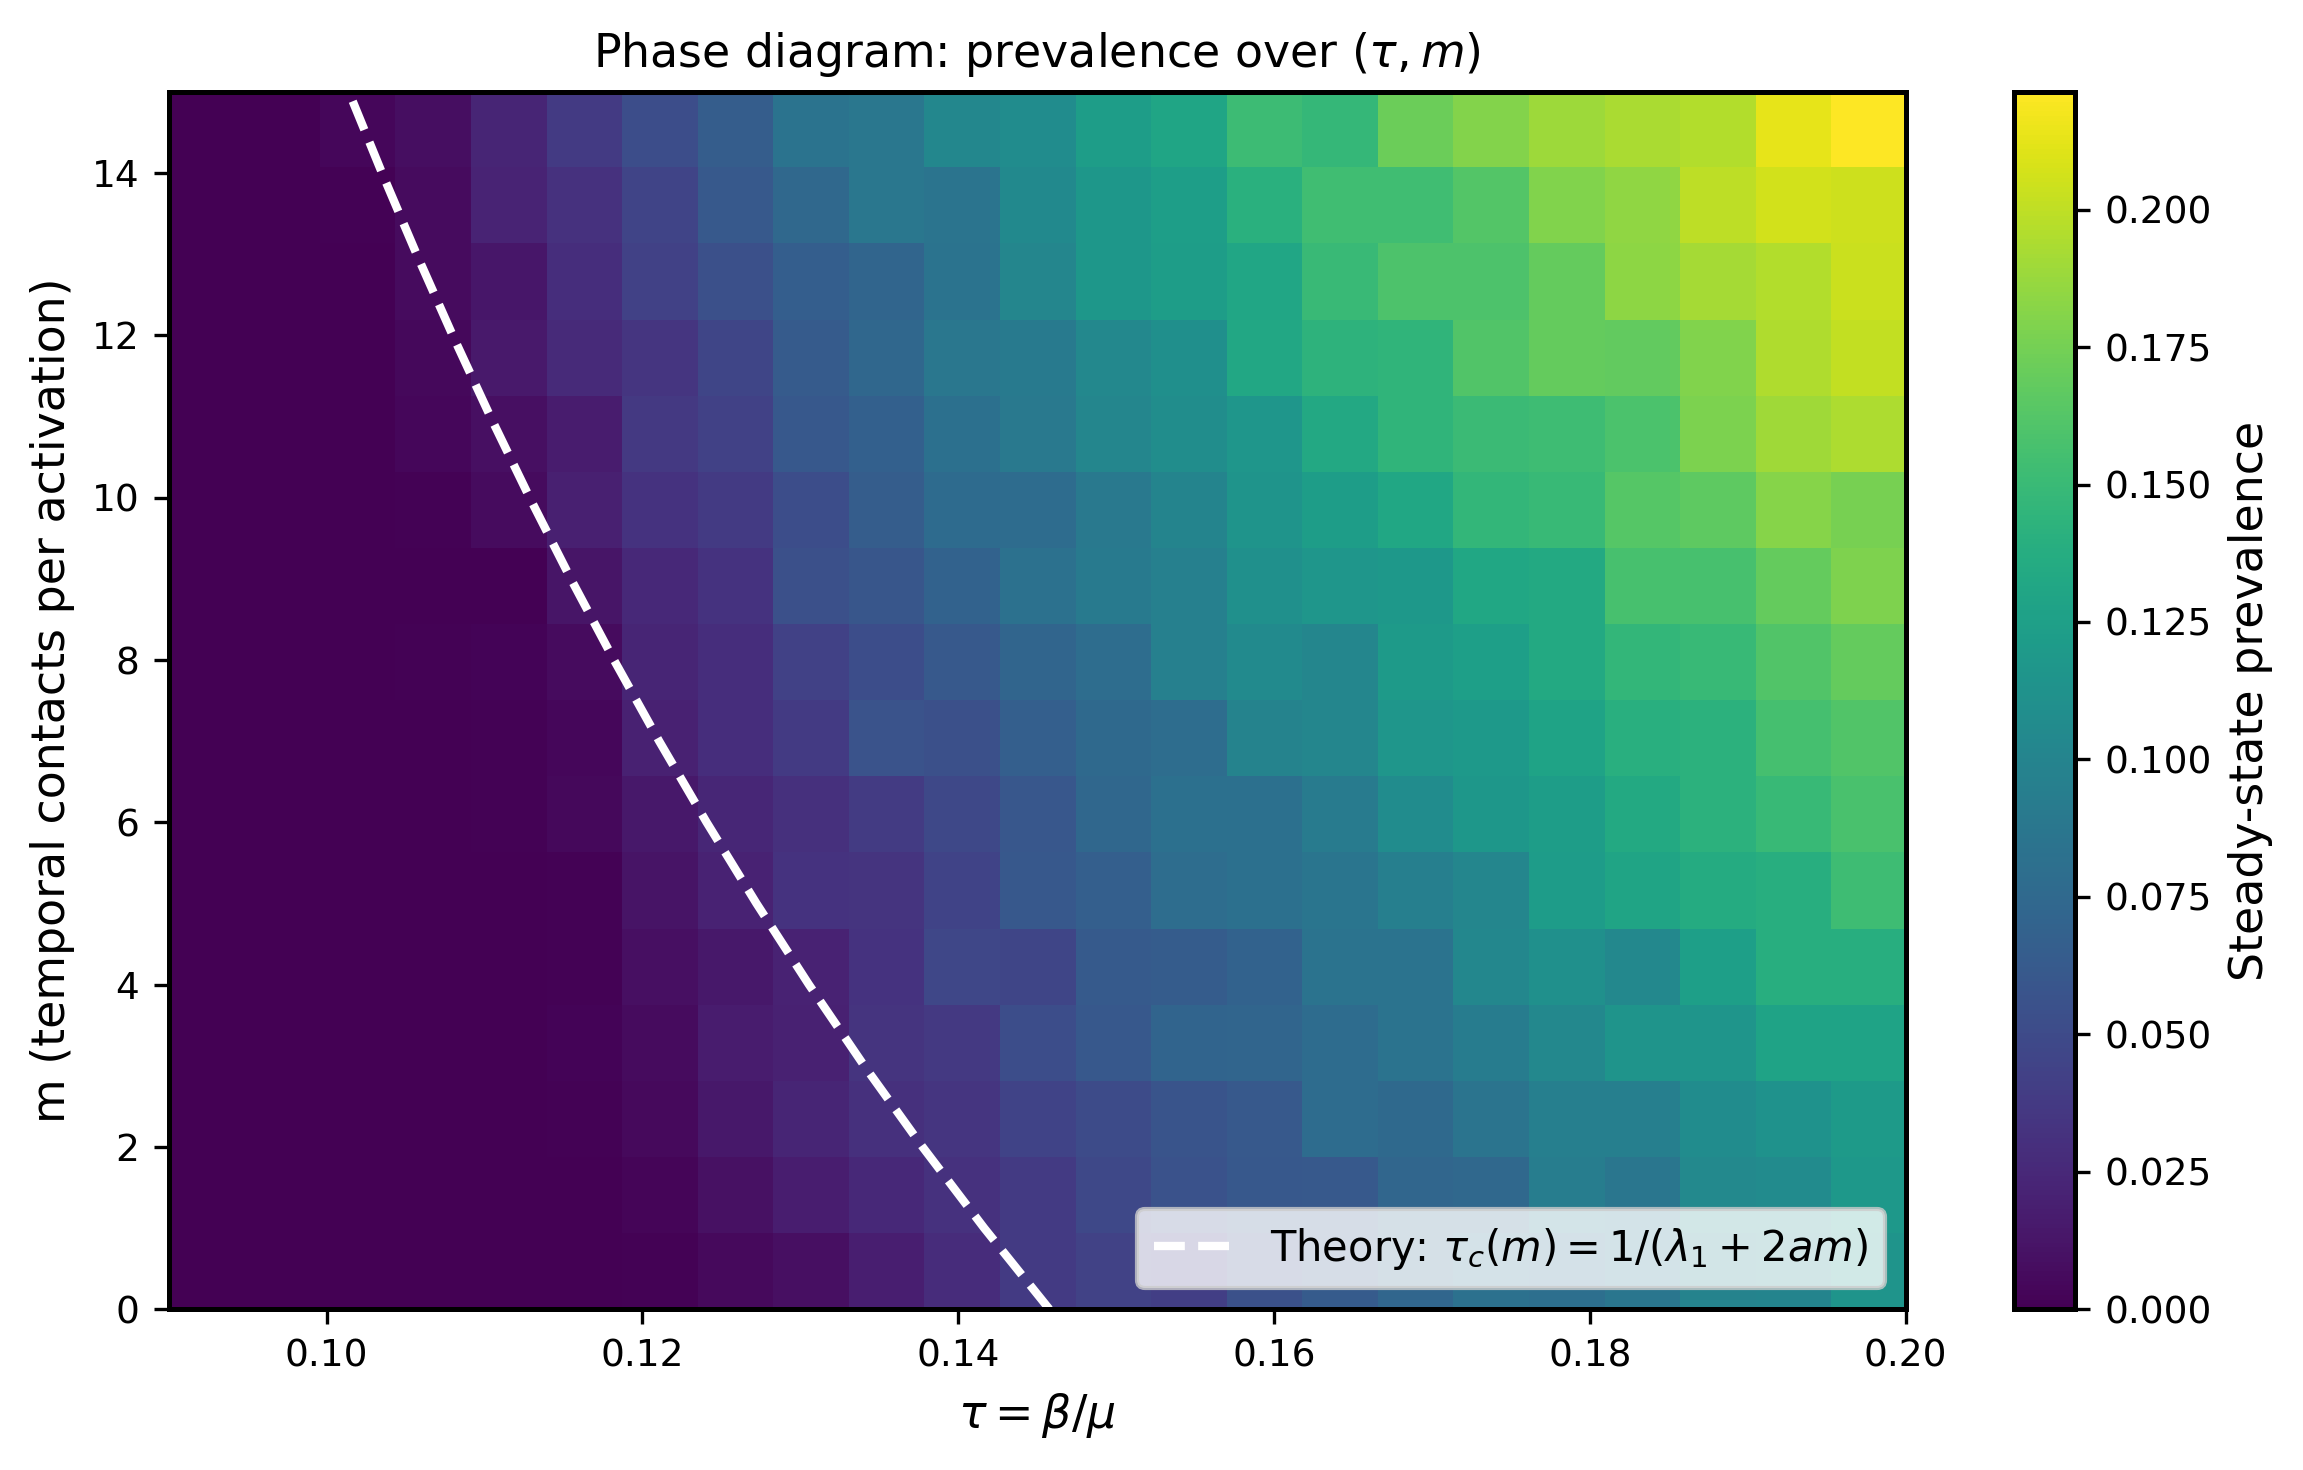

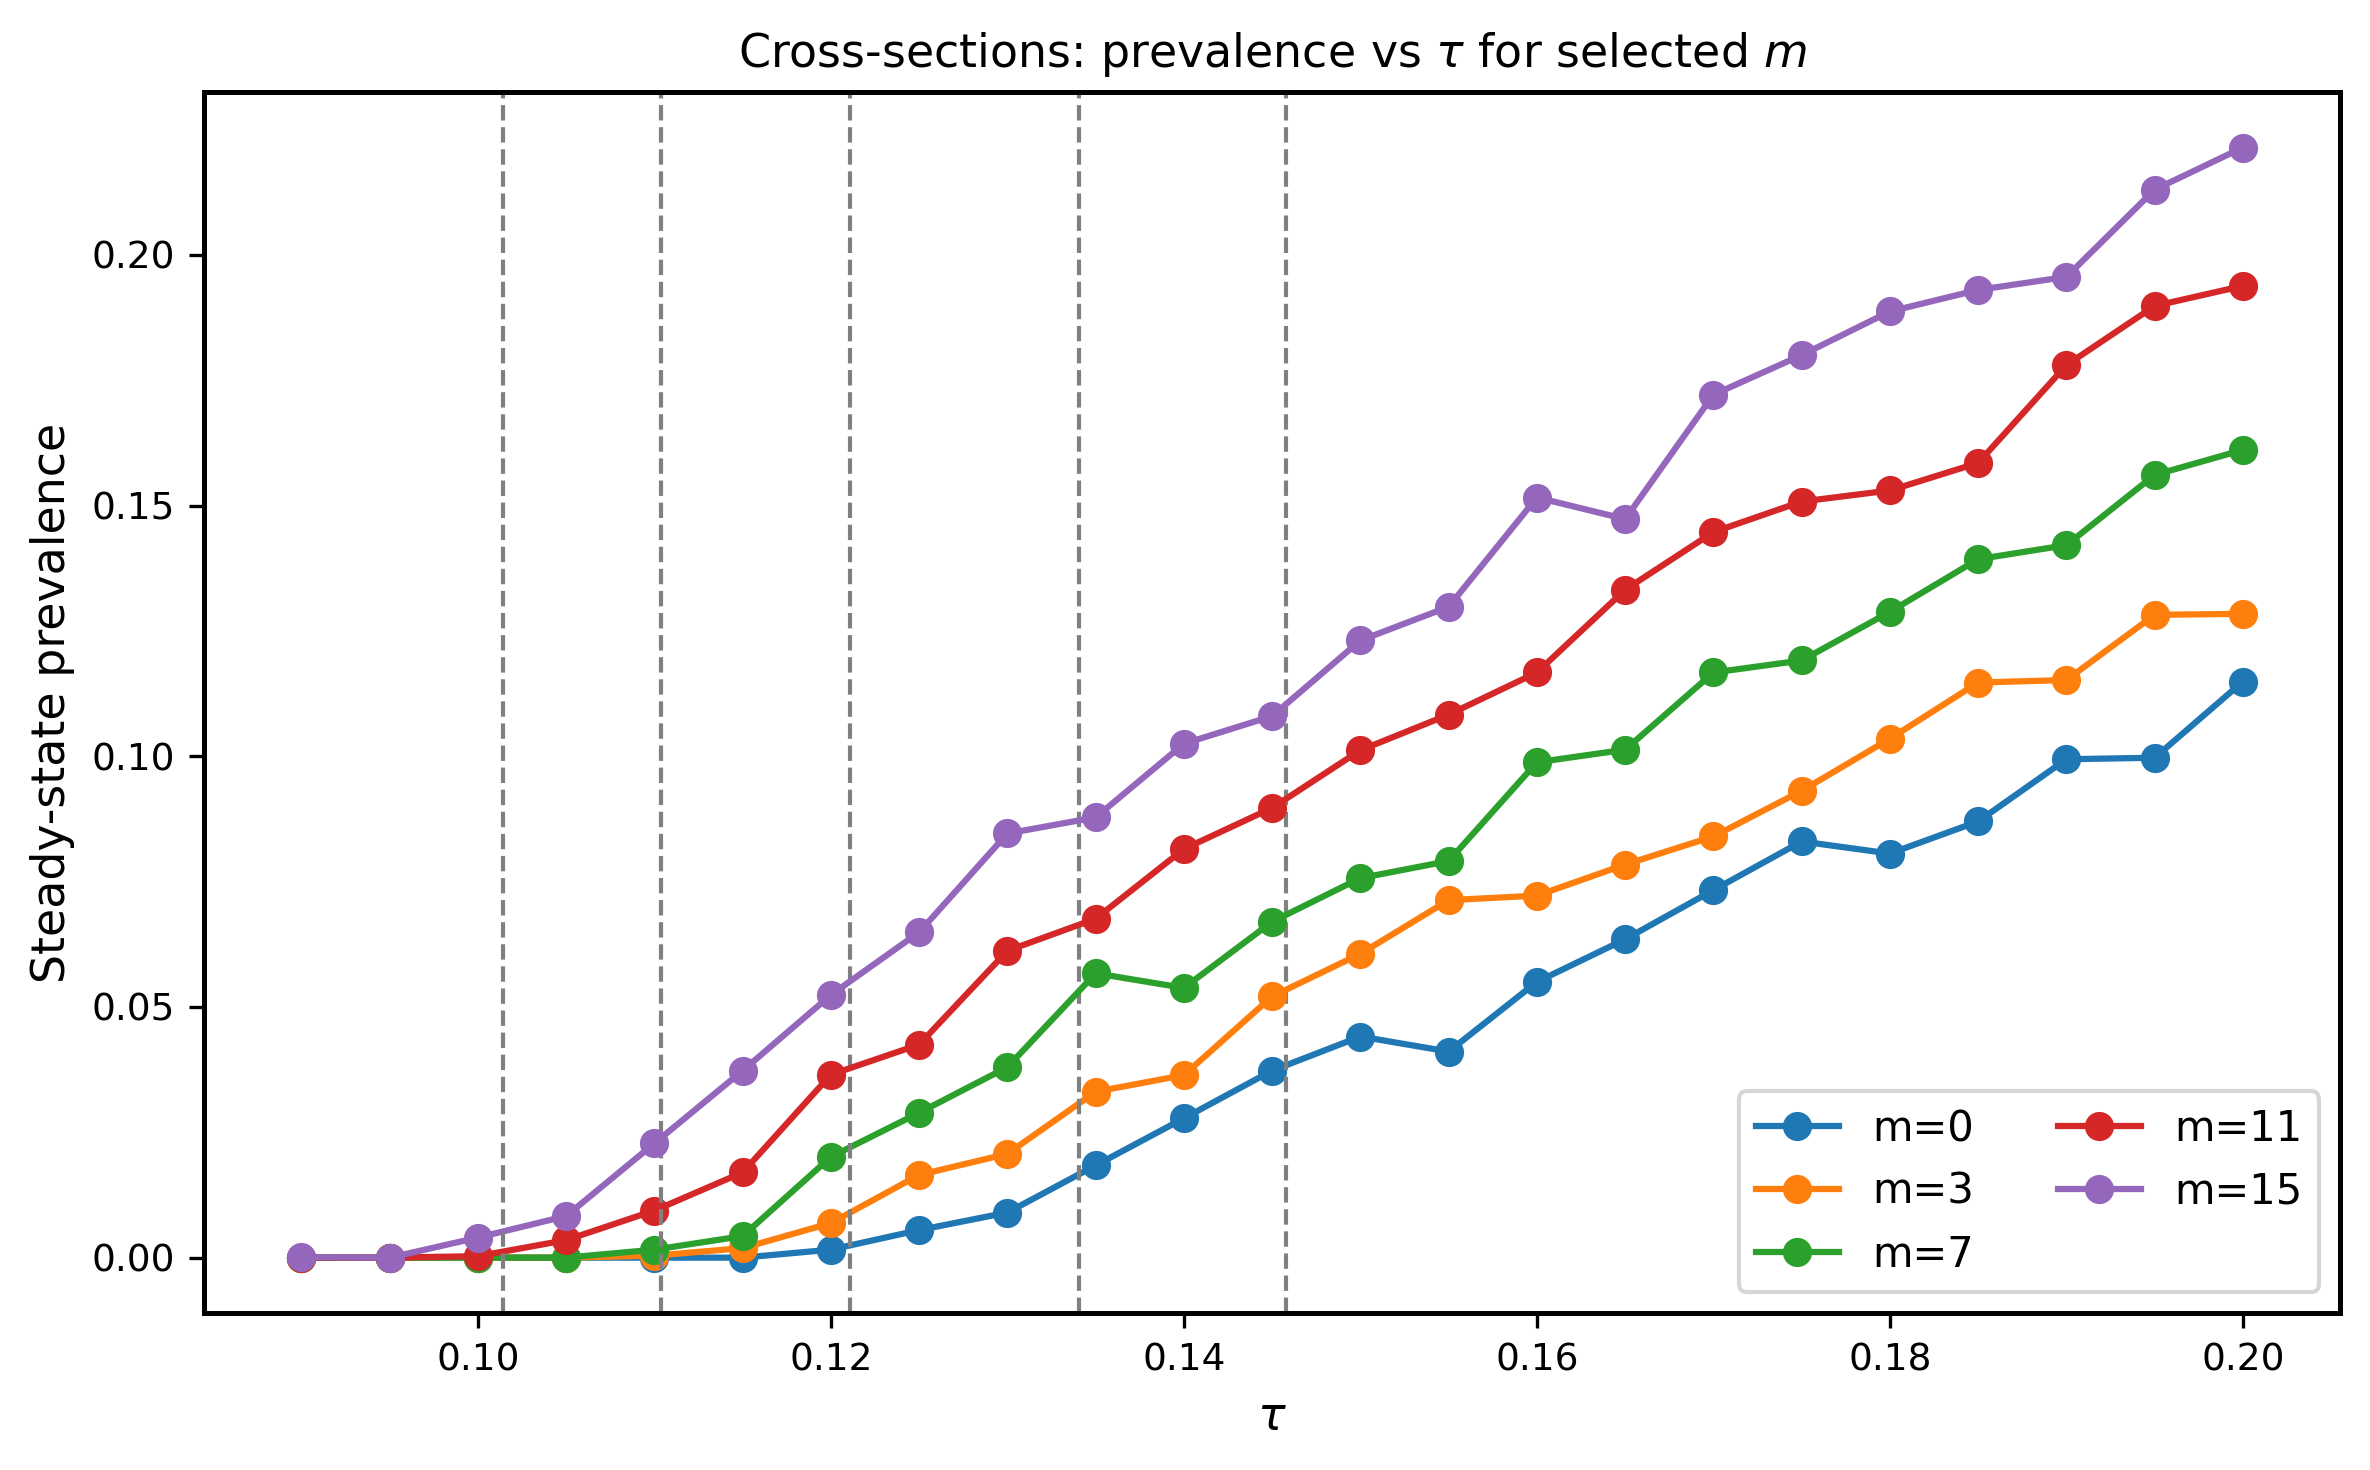

In [15]:
df = pd.read_csv("BA_HM2.csv")
m_c = 7 

tau_sweep(df[df['m'] == 5], 0.11137)
m_sweep(df[df['beta'] == 0.115], m_c)
HeatMap(pd.read_csv("BA_HM2.csv"), lambda1=6.86, a=0.1)

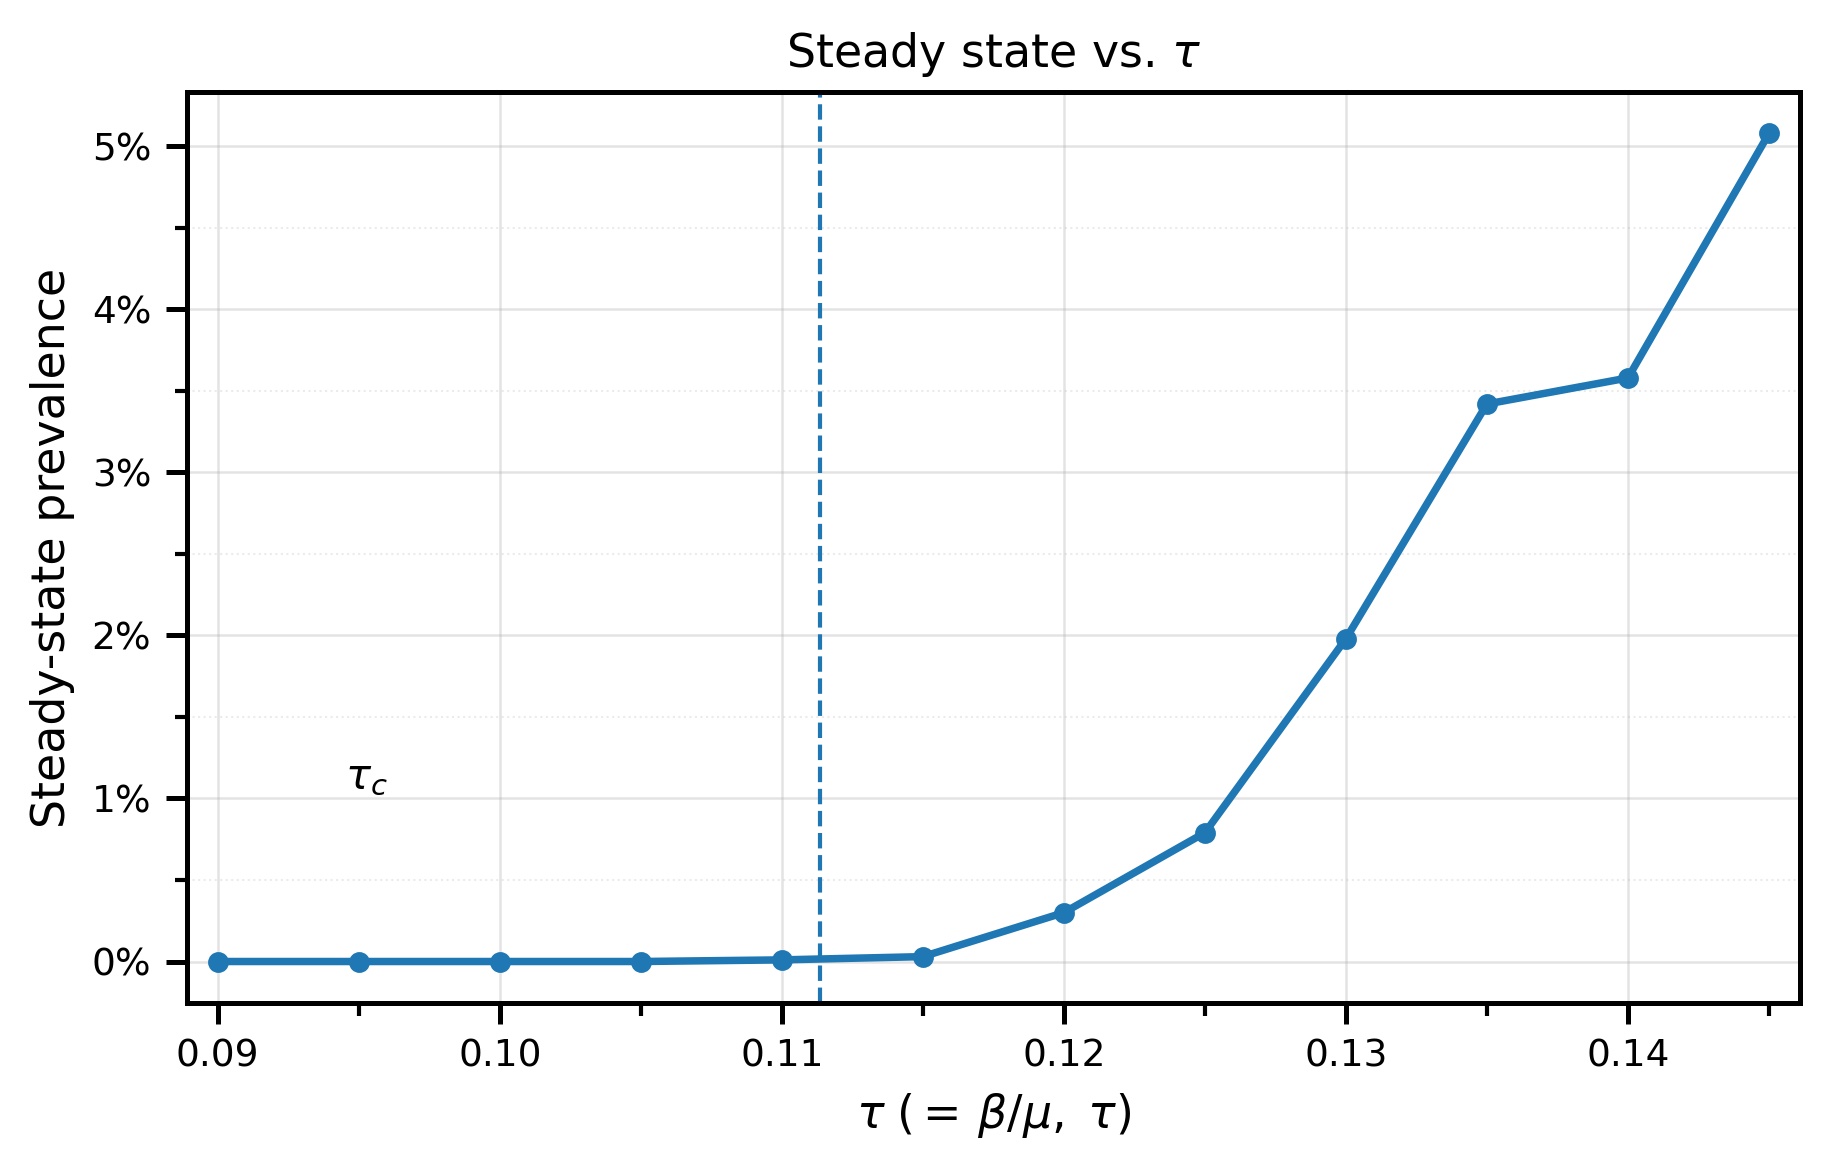

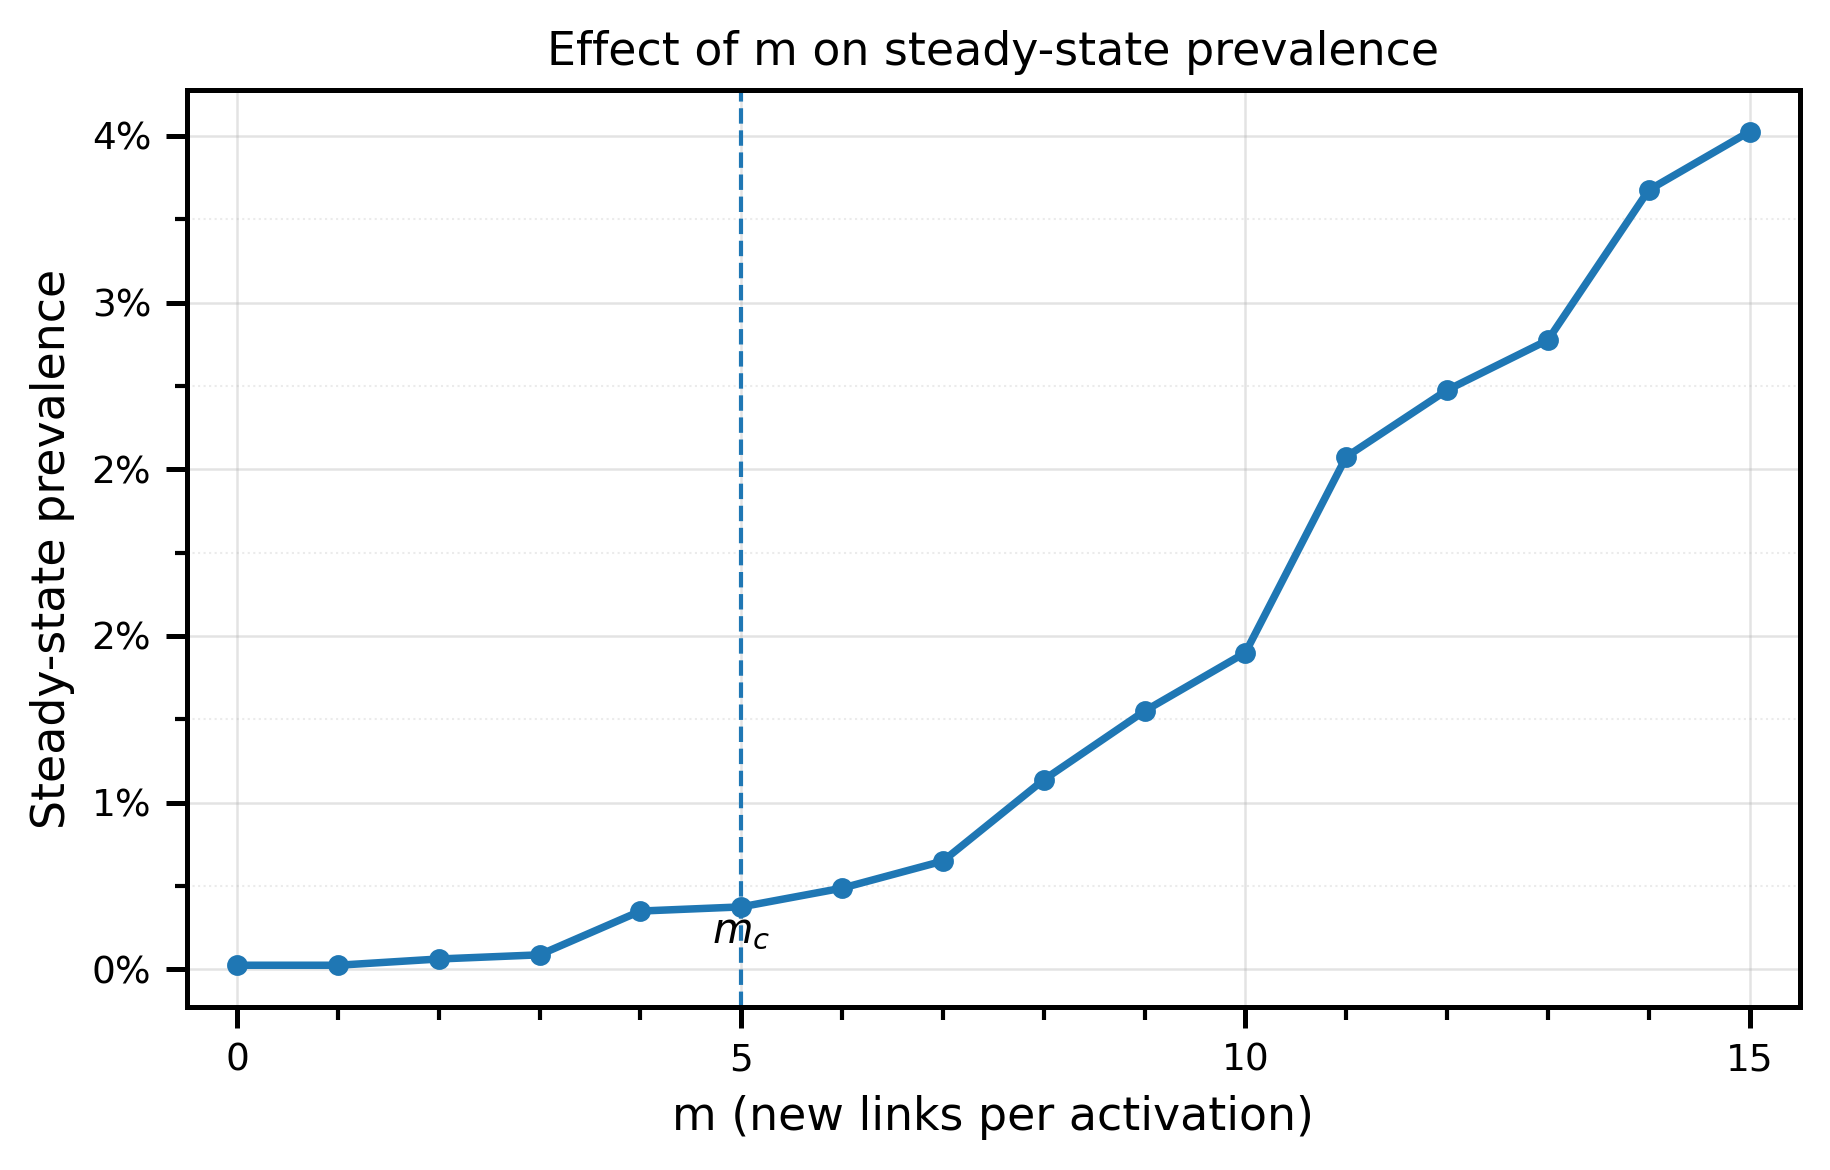

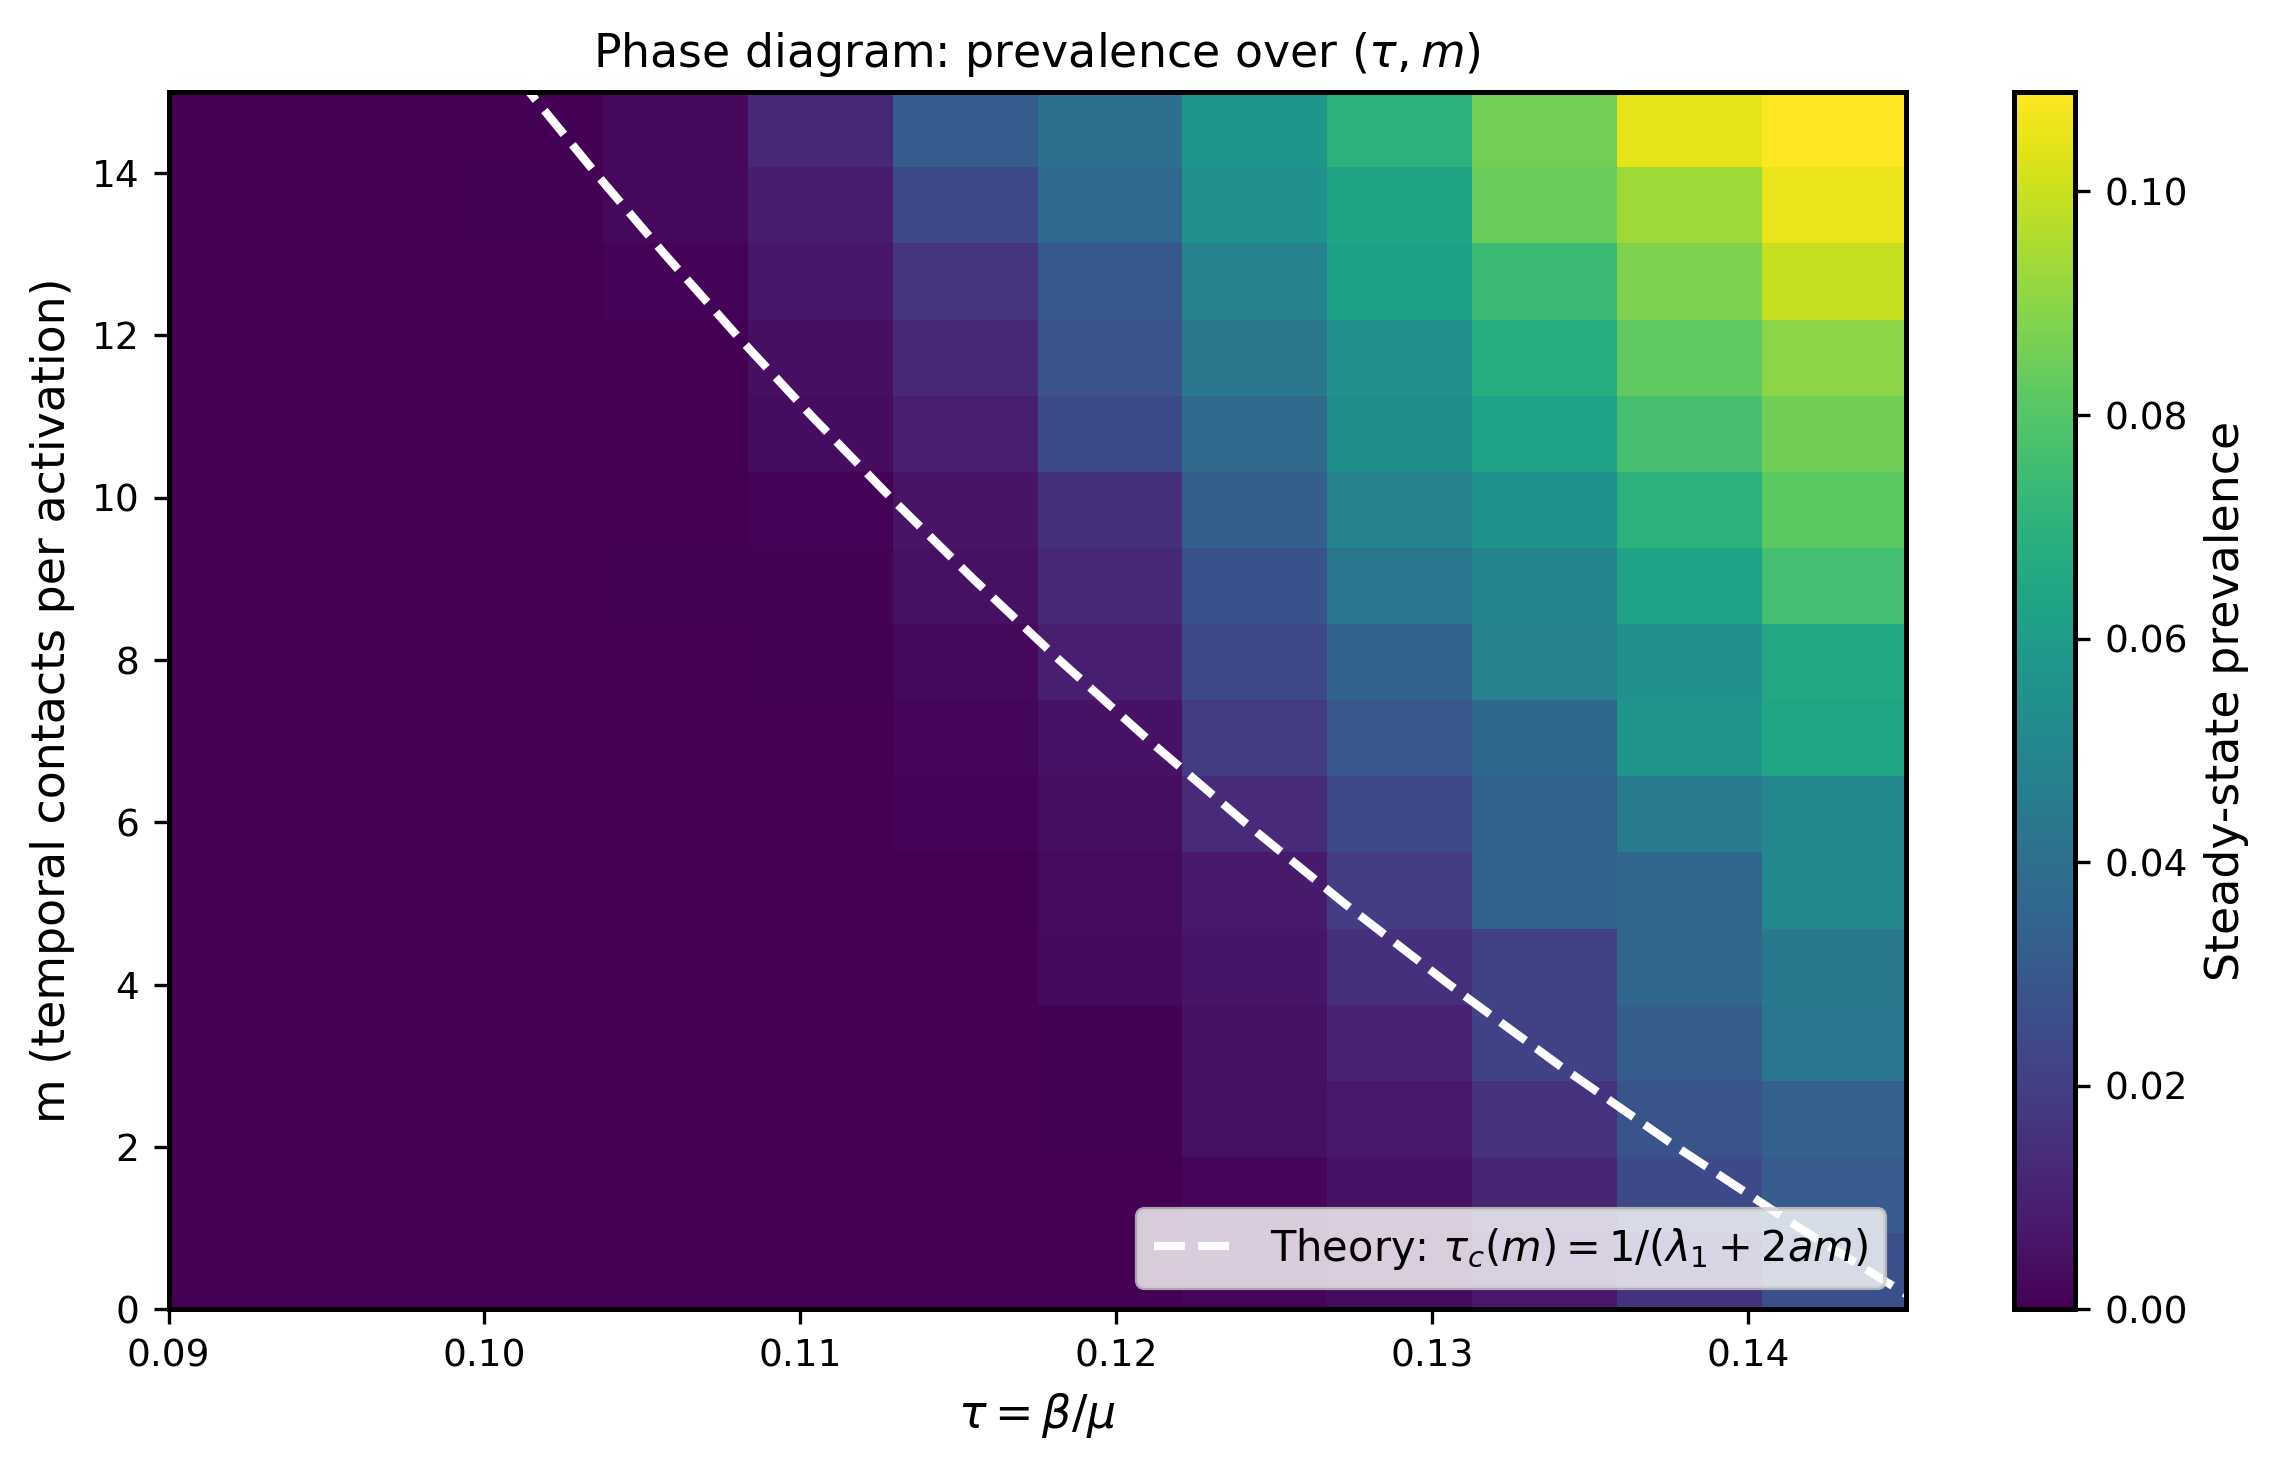

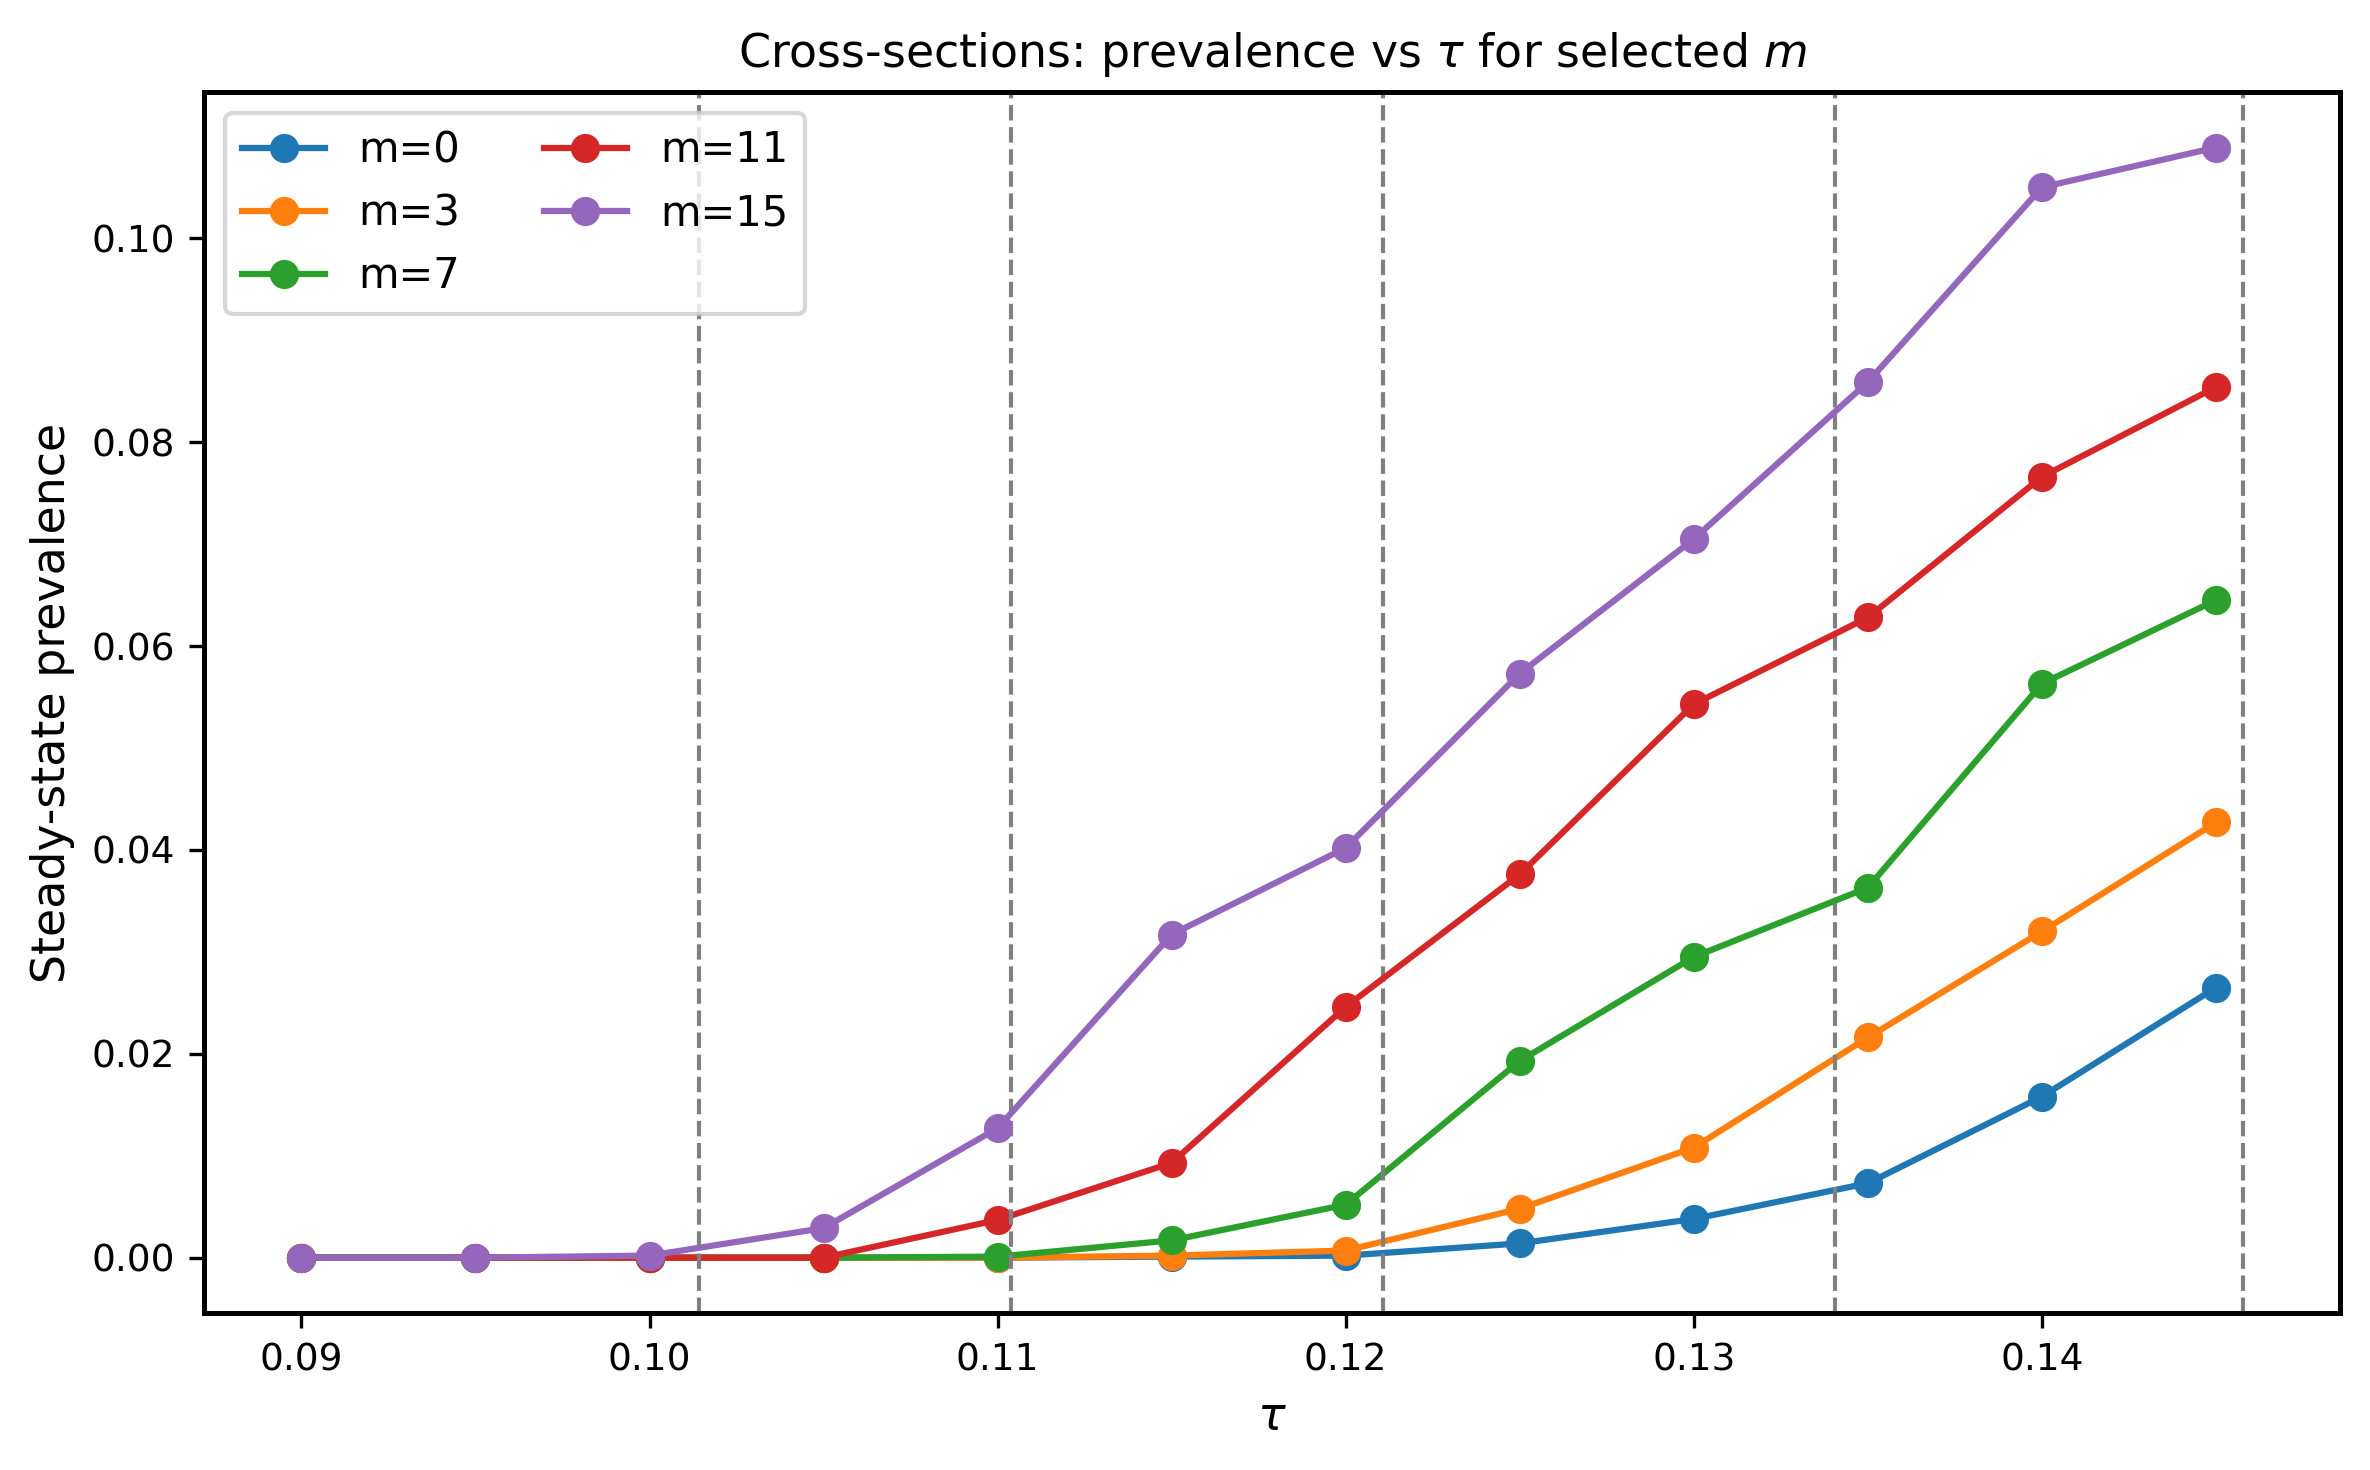

In [ ]:
df = pd.read_csv("BA_HM.csv")
m_c = 7 

tau_sweep(df[df['m'] == 5], 0.11137)
m_sweep(df[df['beta'] == 0.12], m_c)
HeatMap(pd.read_csv("BA_HM.csv"), lambda1=6.86, a=0.1)

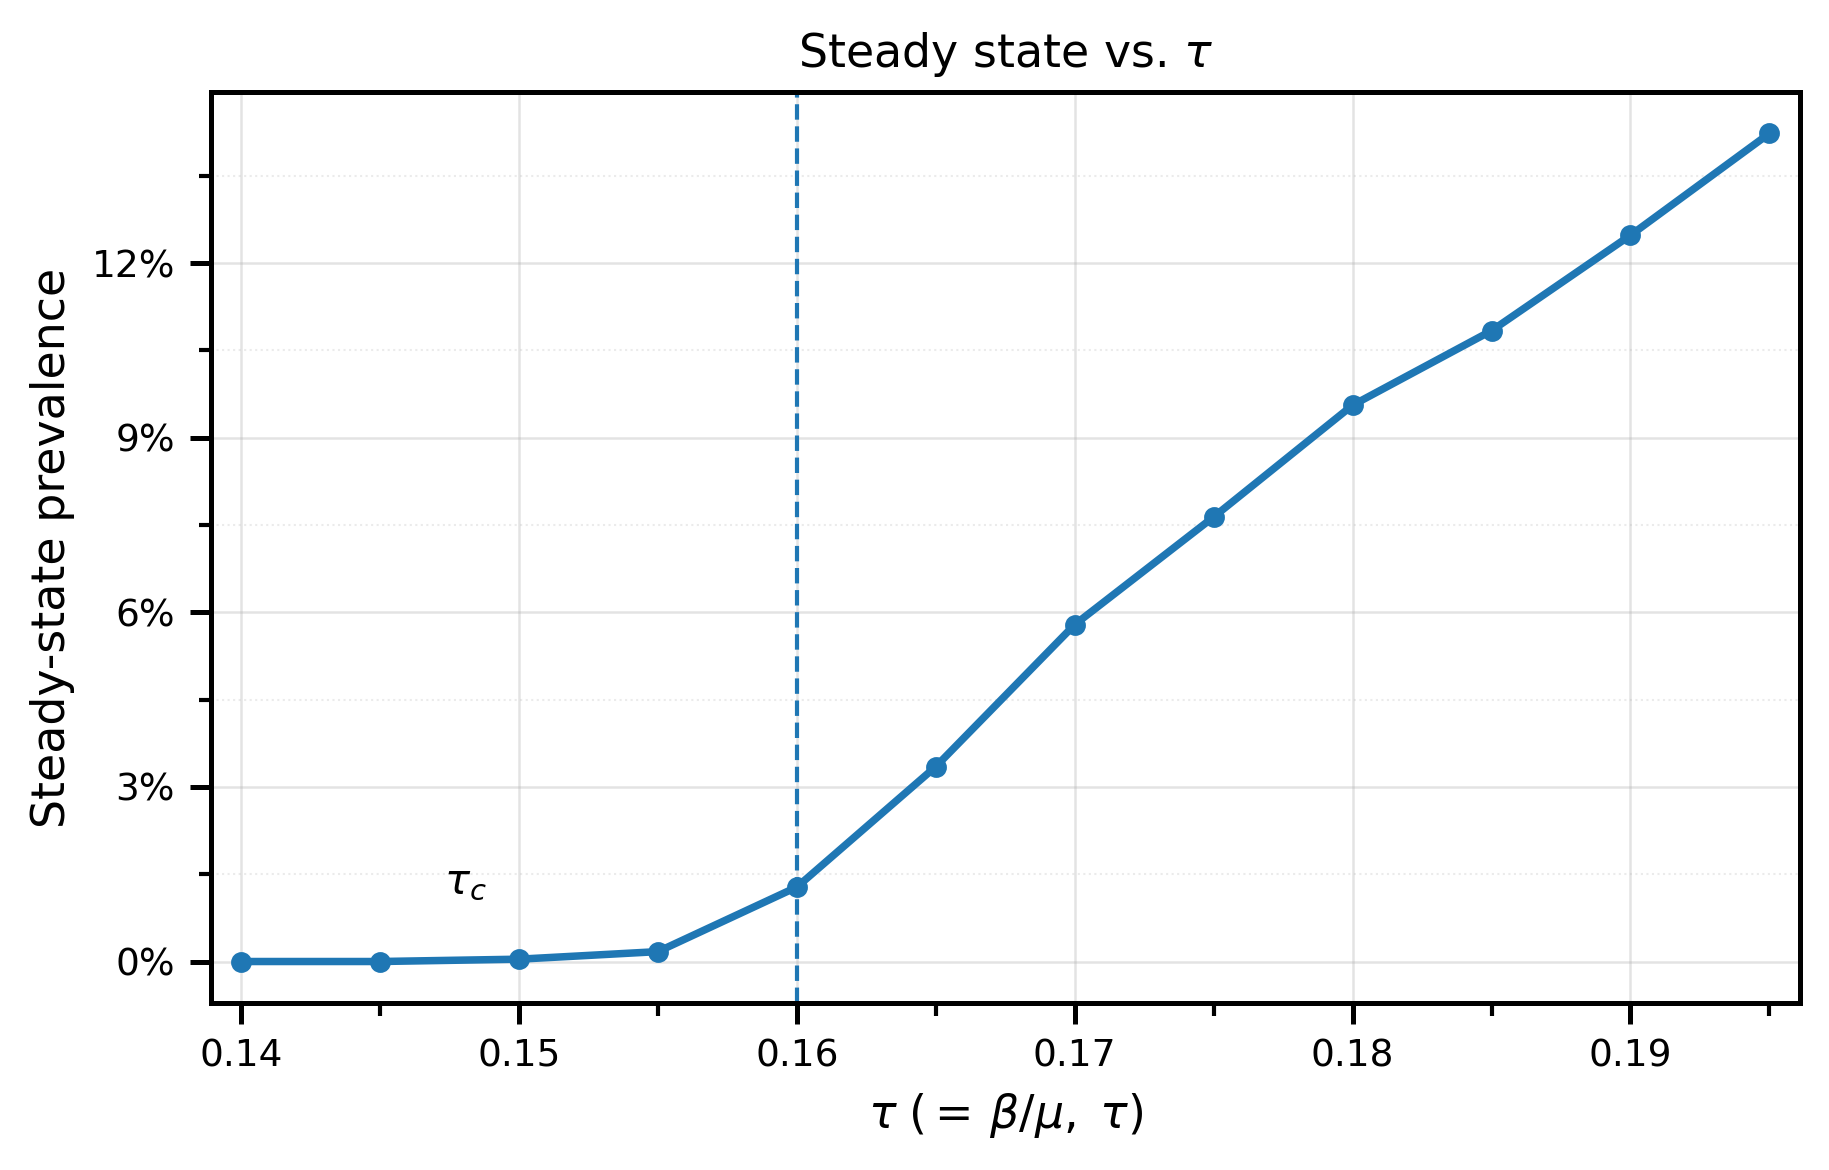

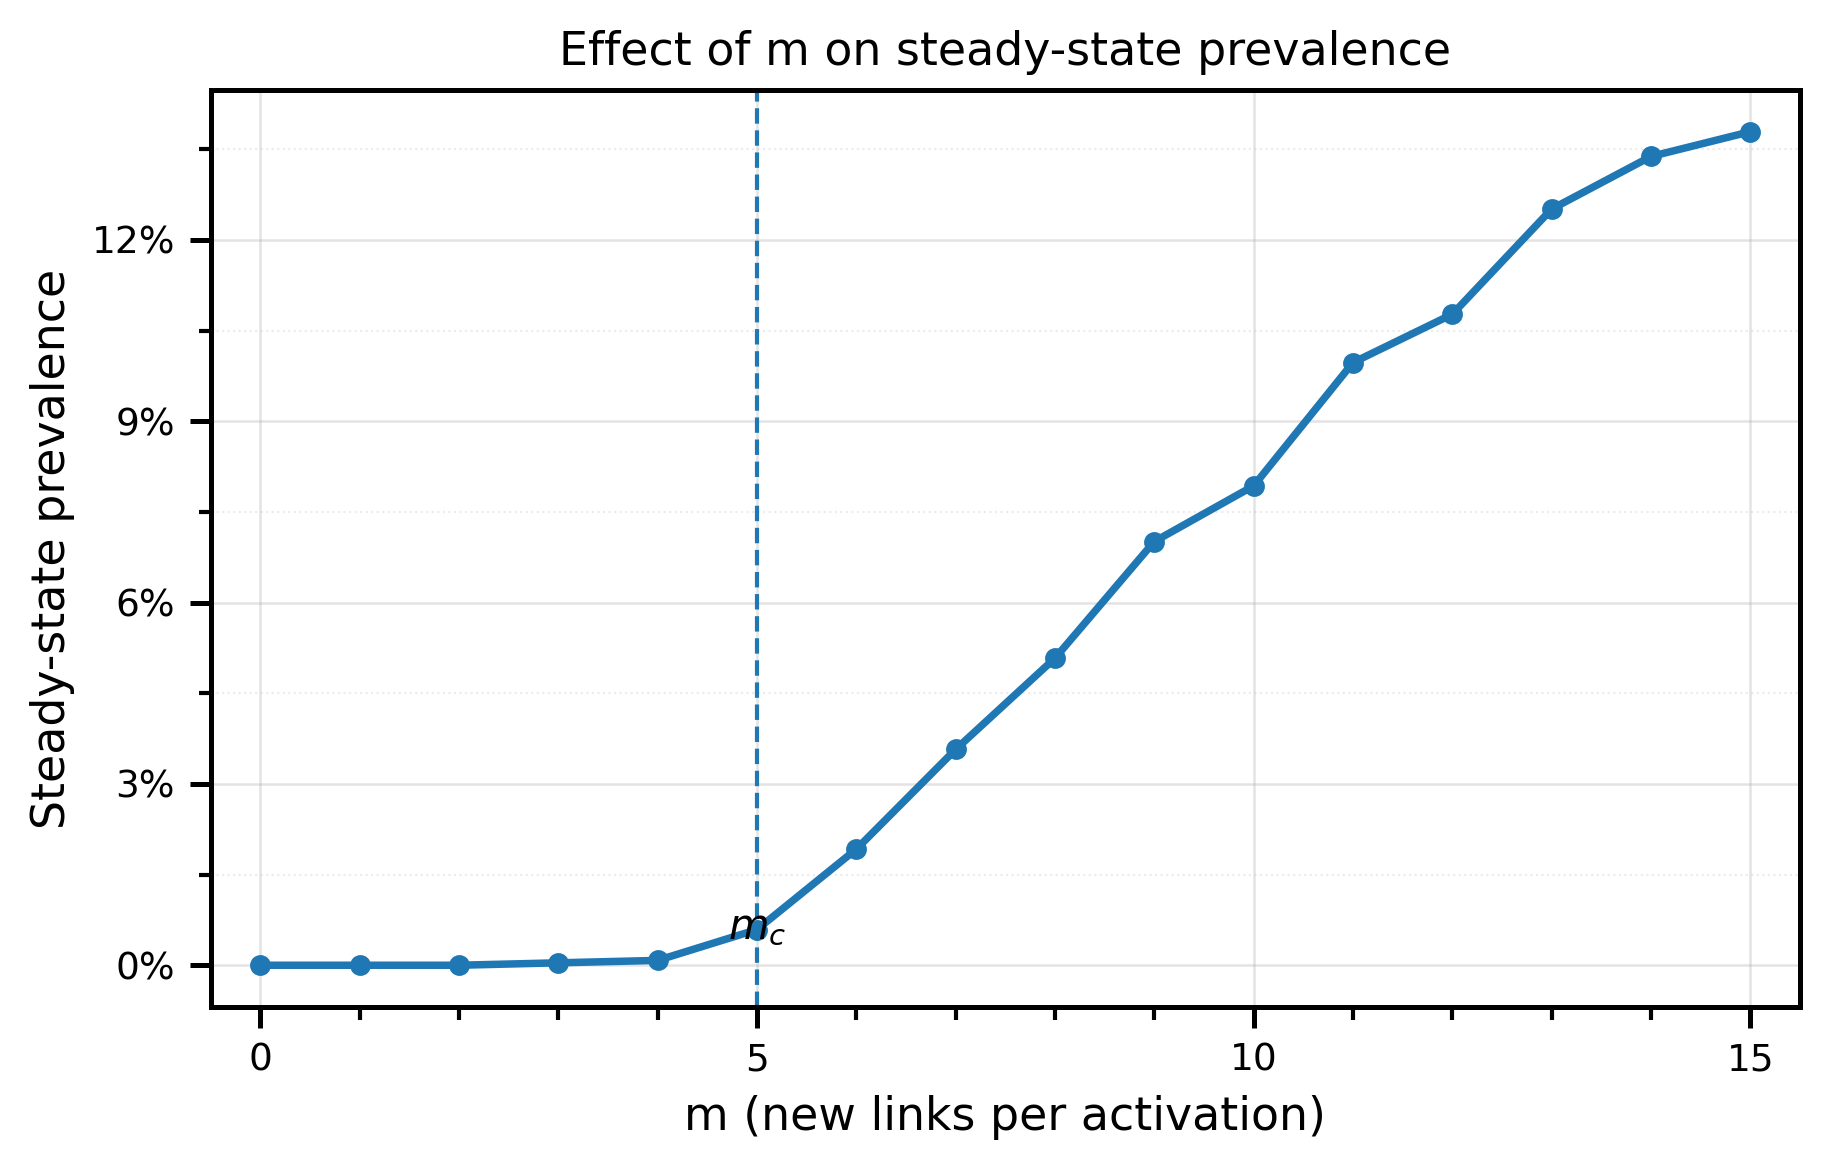

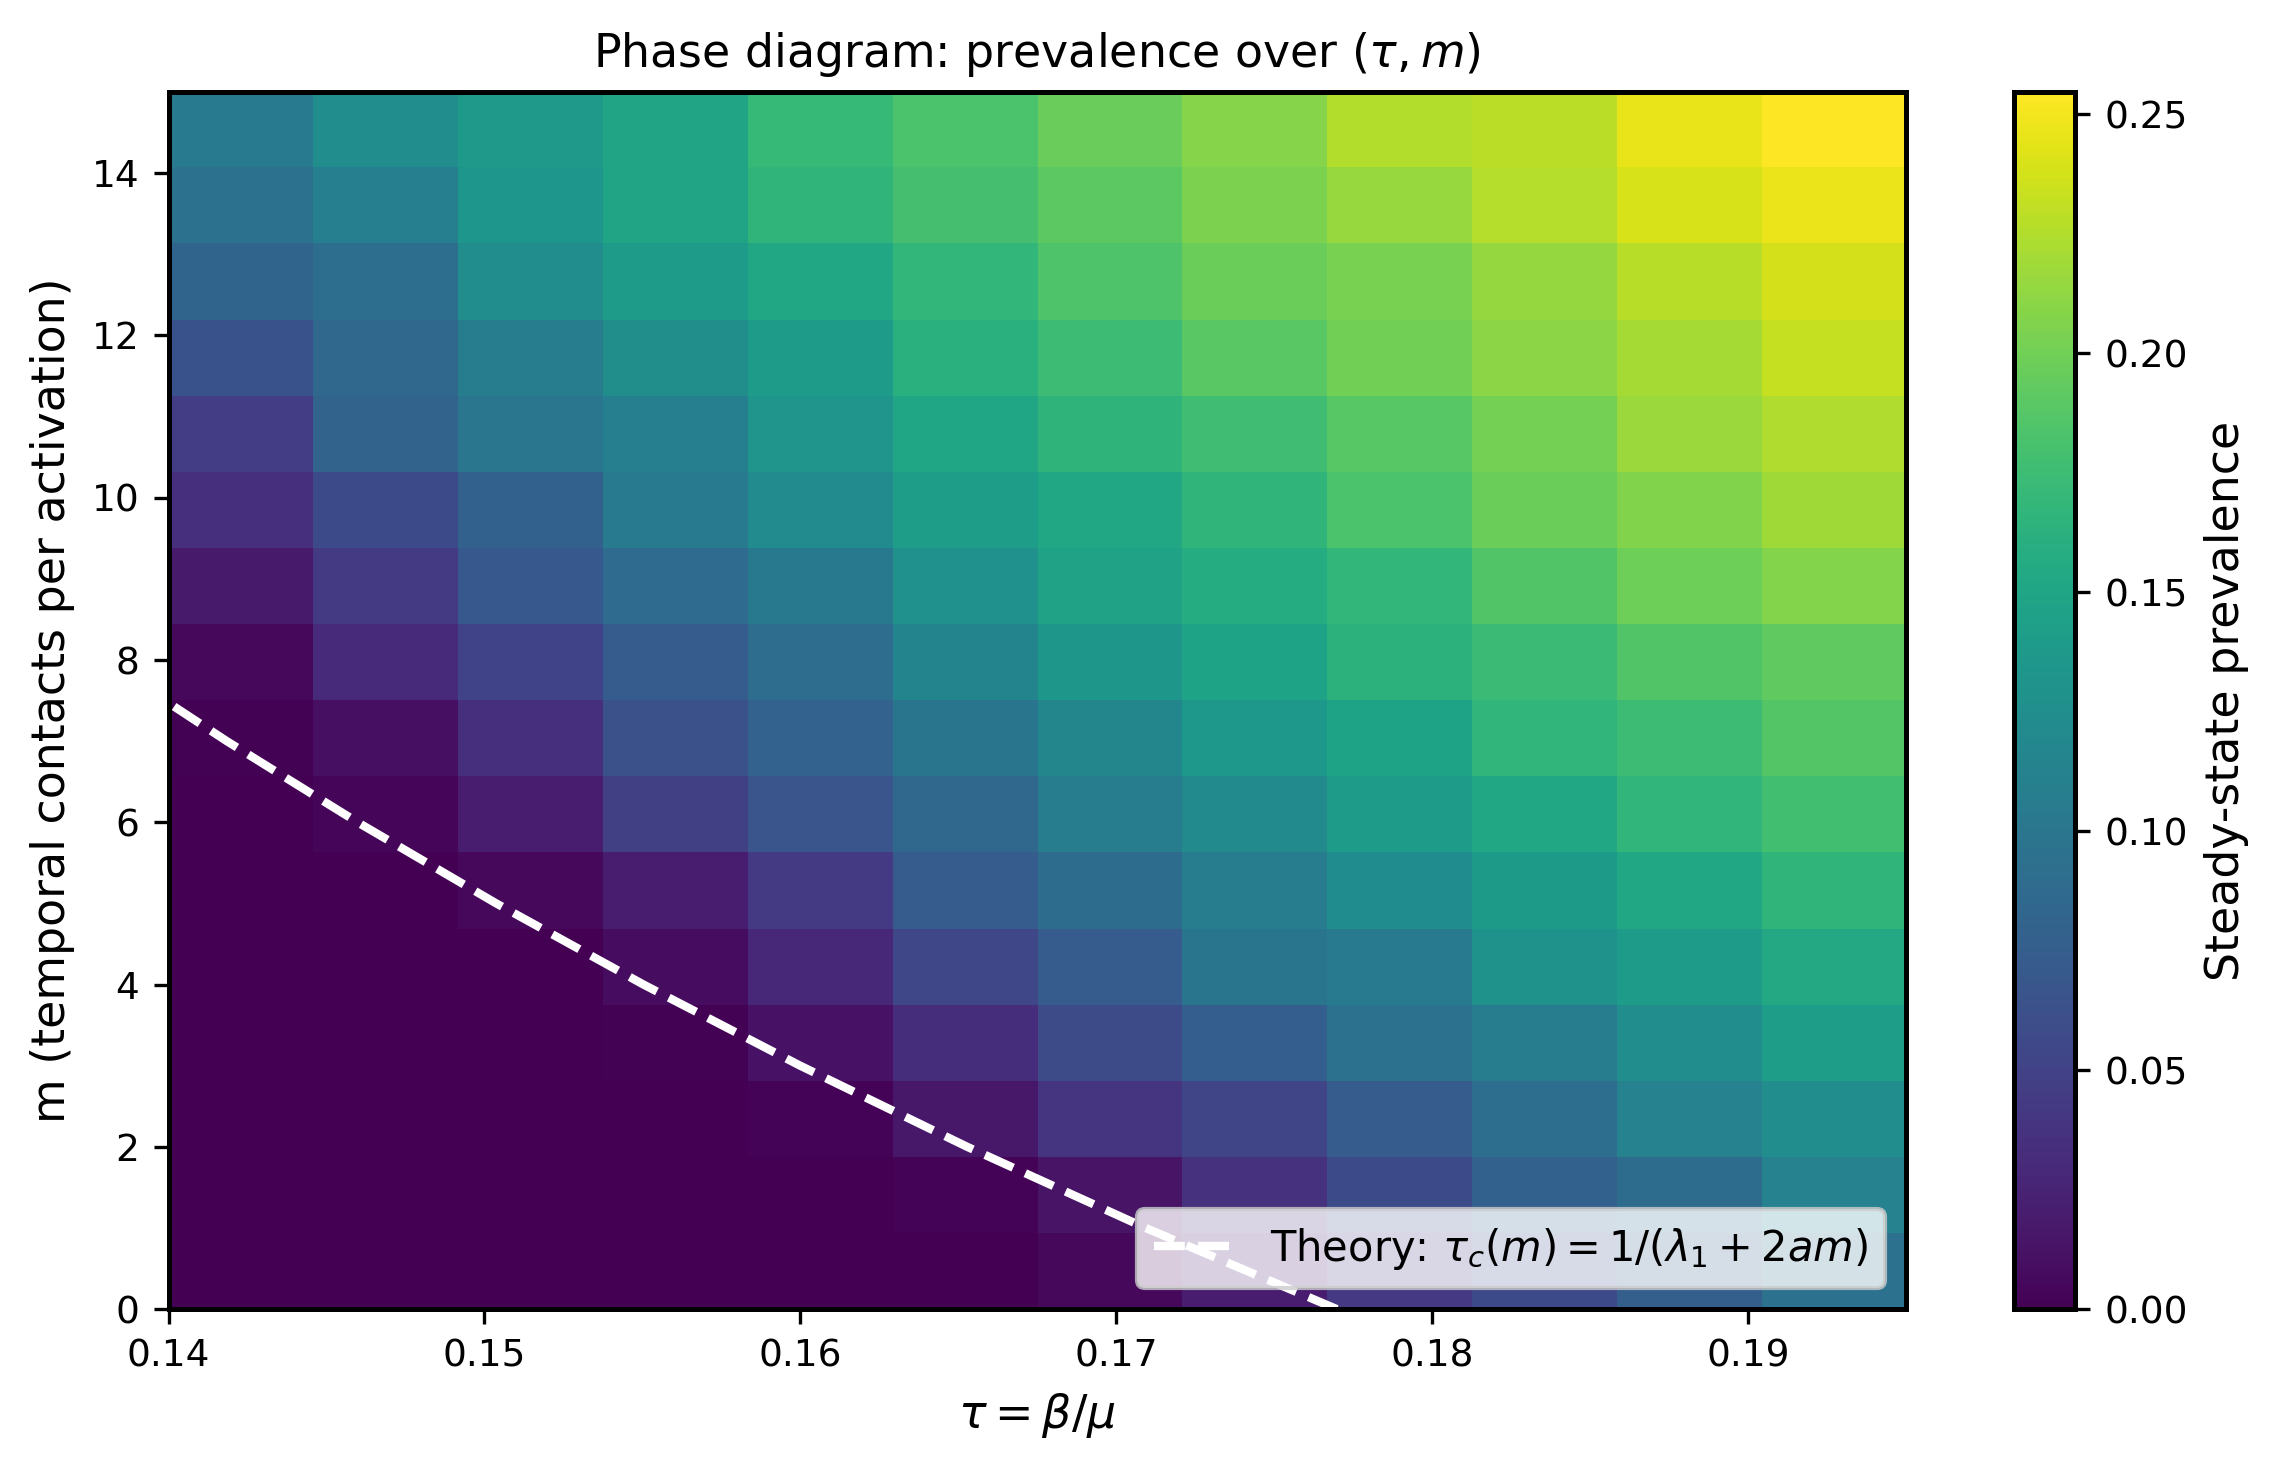

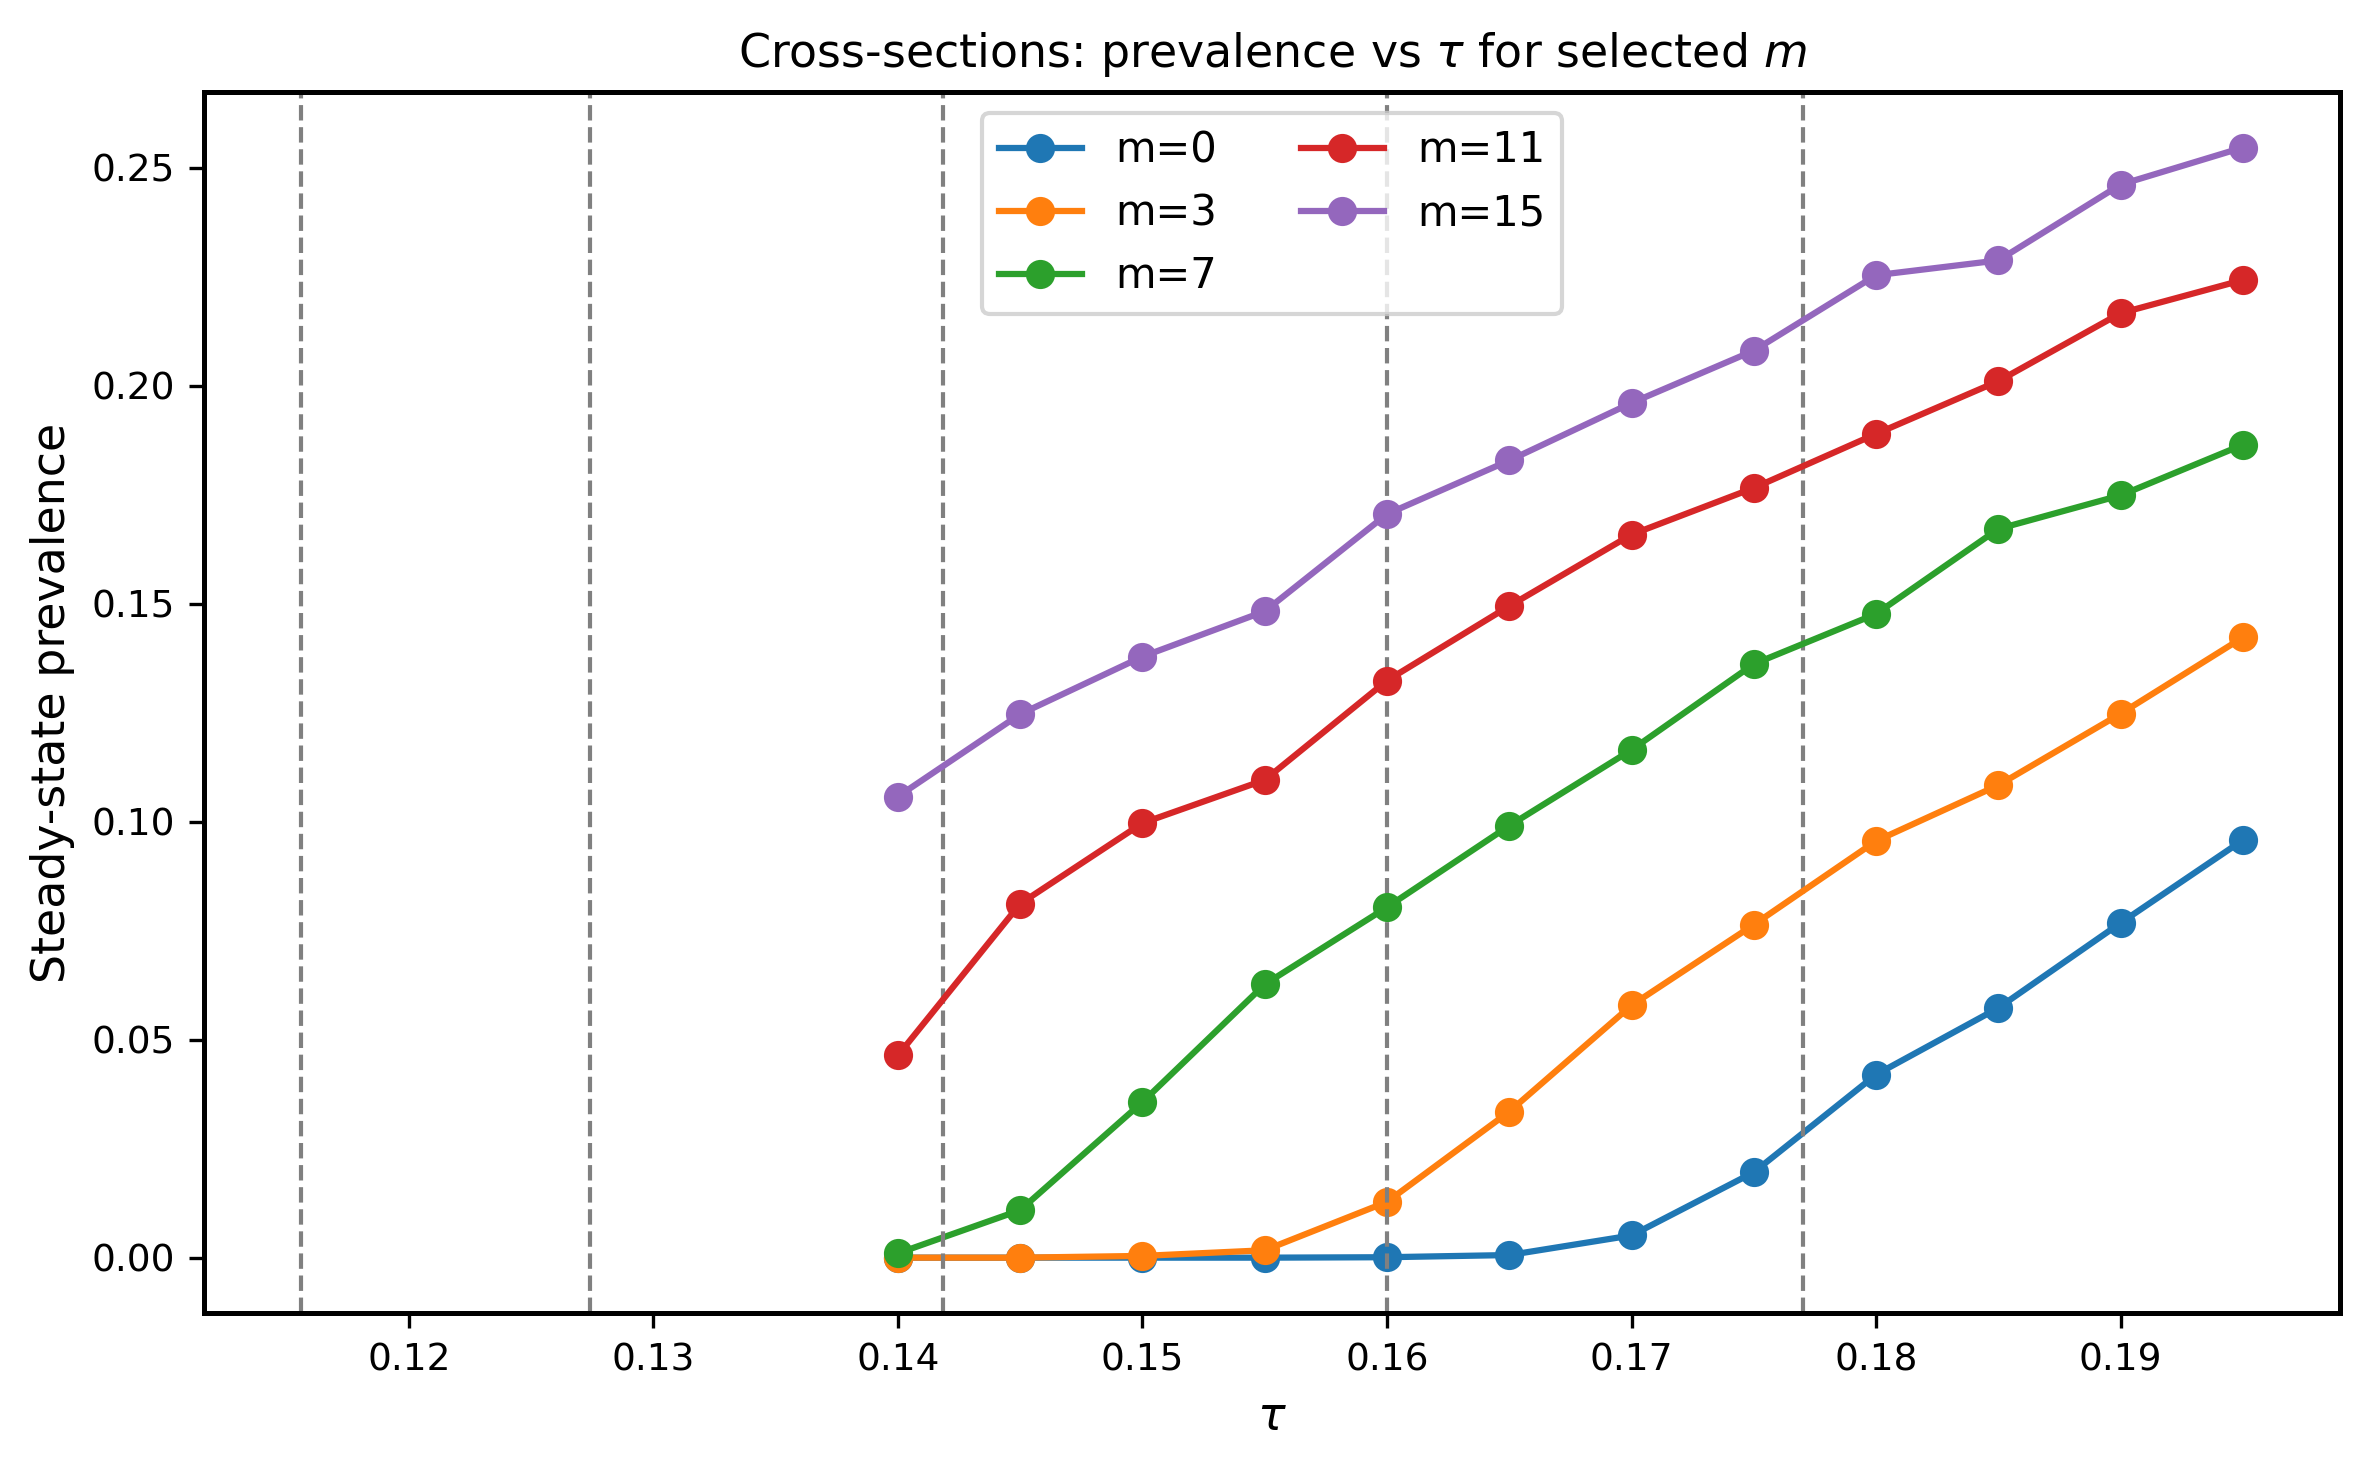

In [38]:
df = pd.read_csv("ER_HM.csv")
m_c = 3 

tau_sweep(df[df['m'] == 3], 0.16)
m_sweep(df[df['beta'] == 0.15], m_c)
HeatMap(pd.read_csv("ER_HM.csv"), lambda1=5.65, a=0.1)

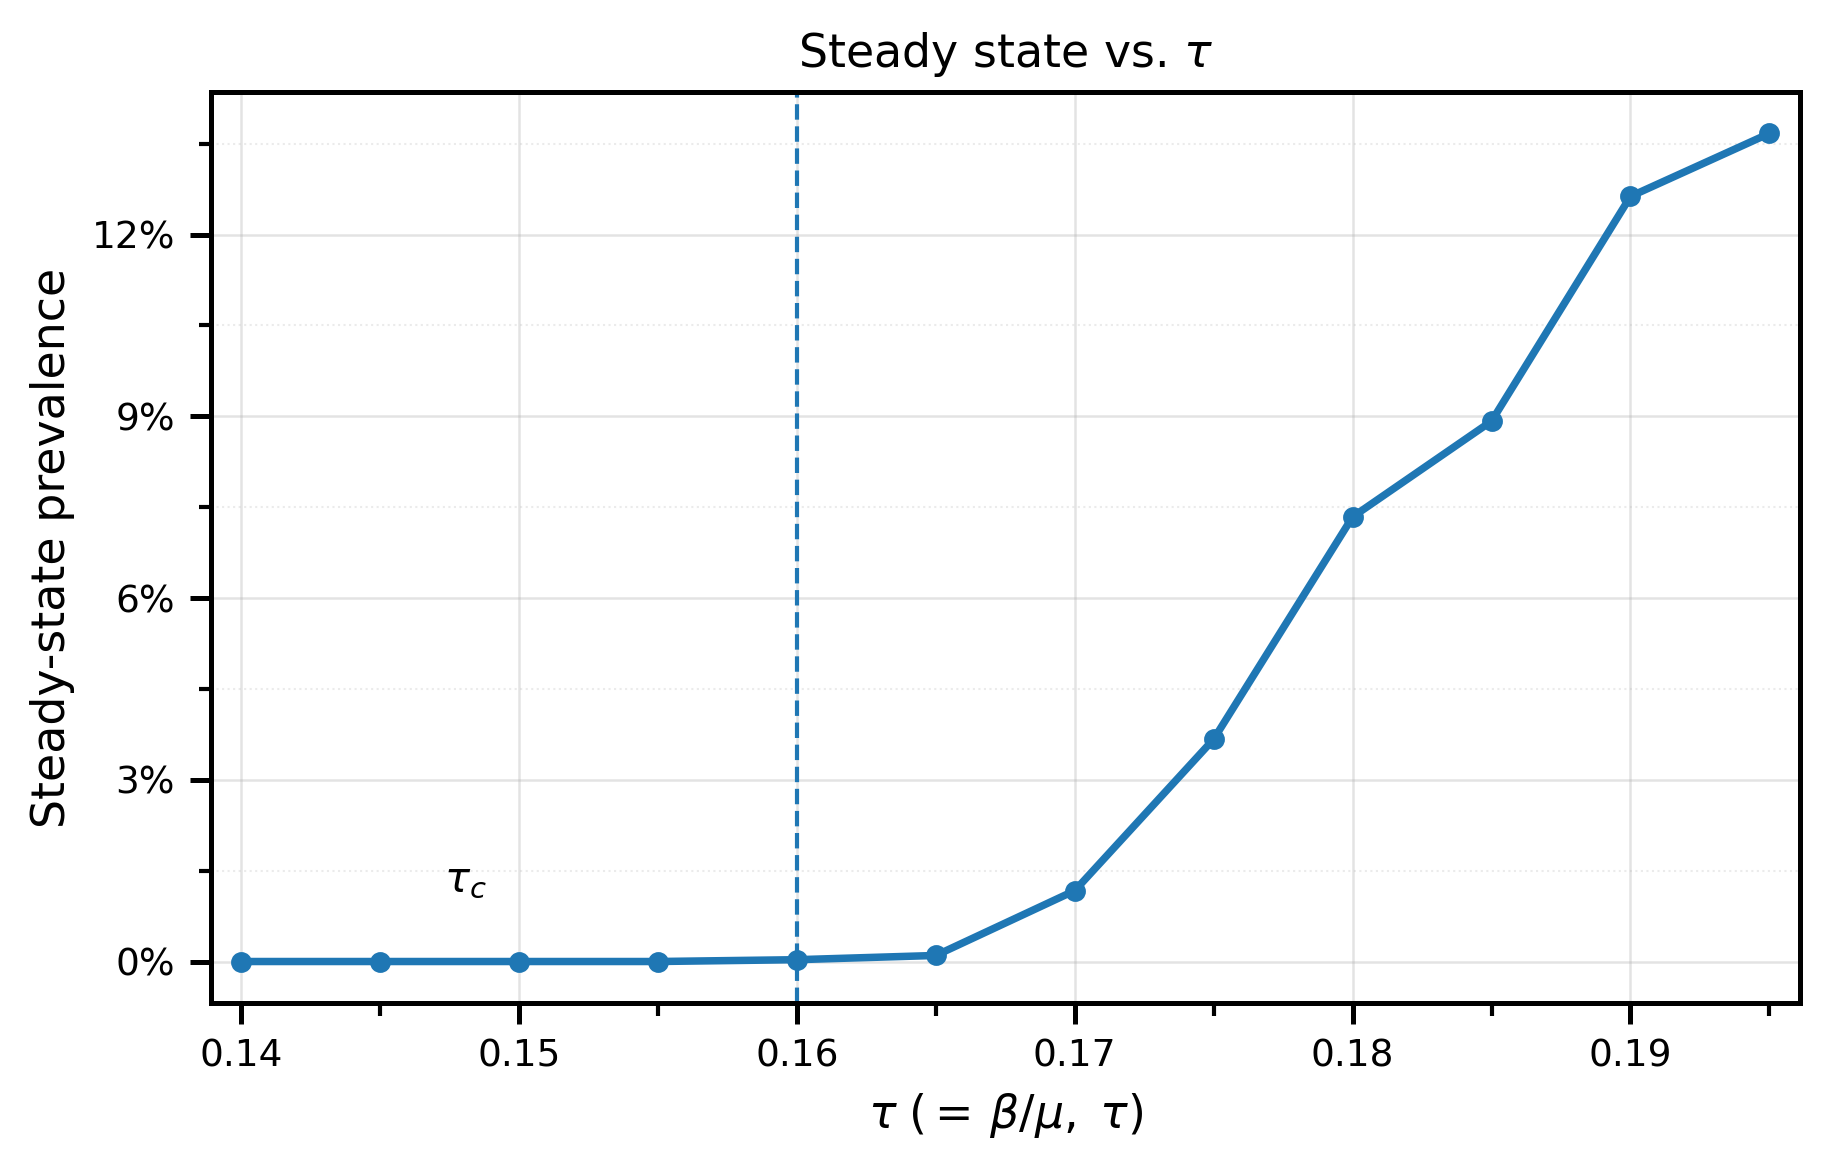

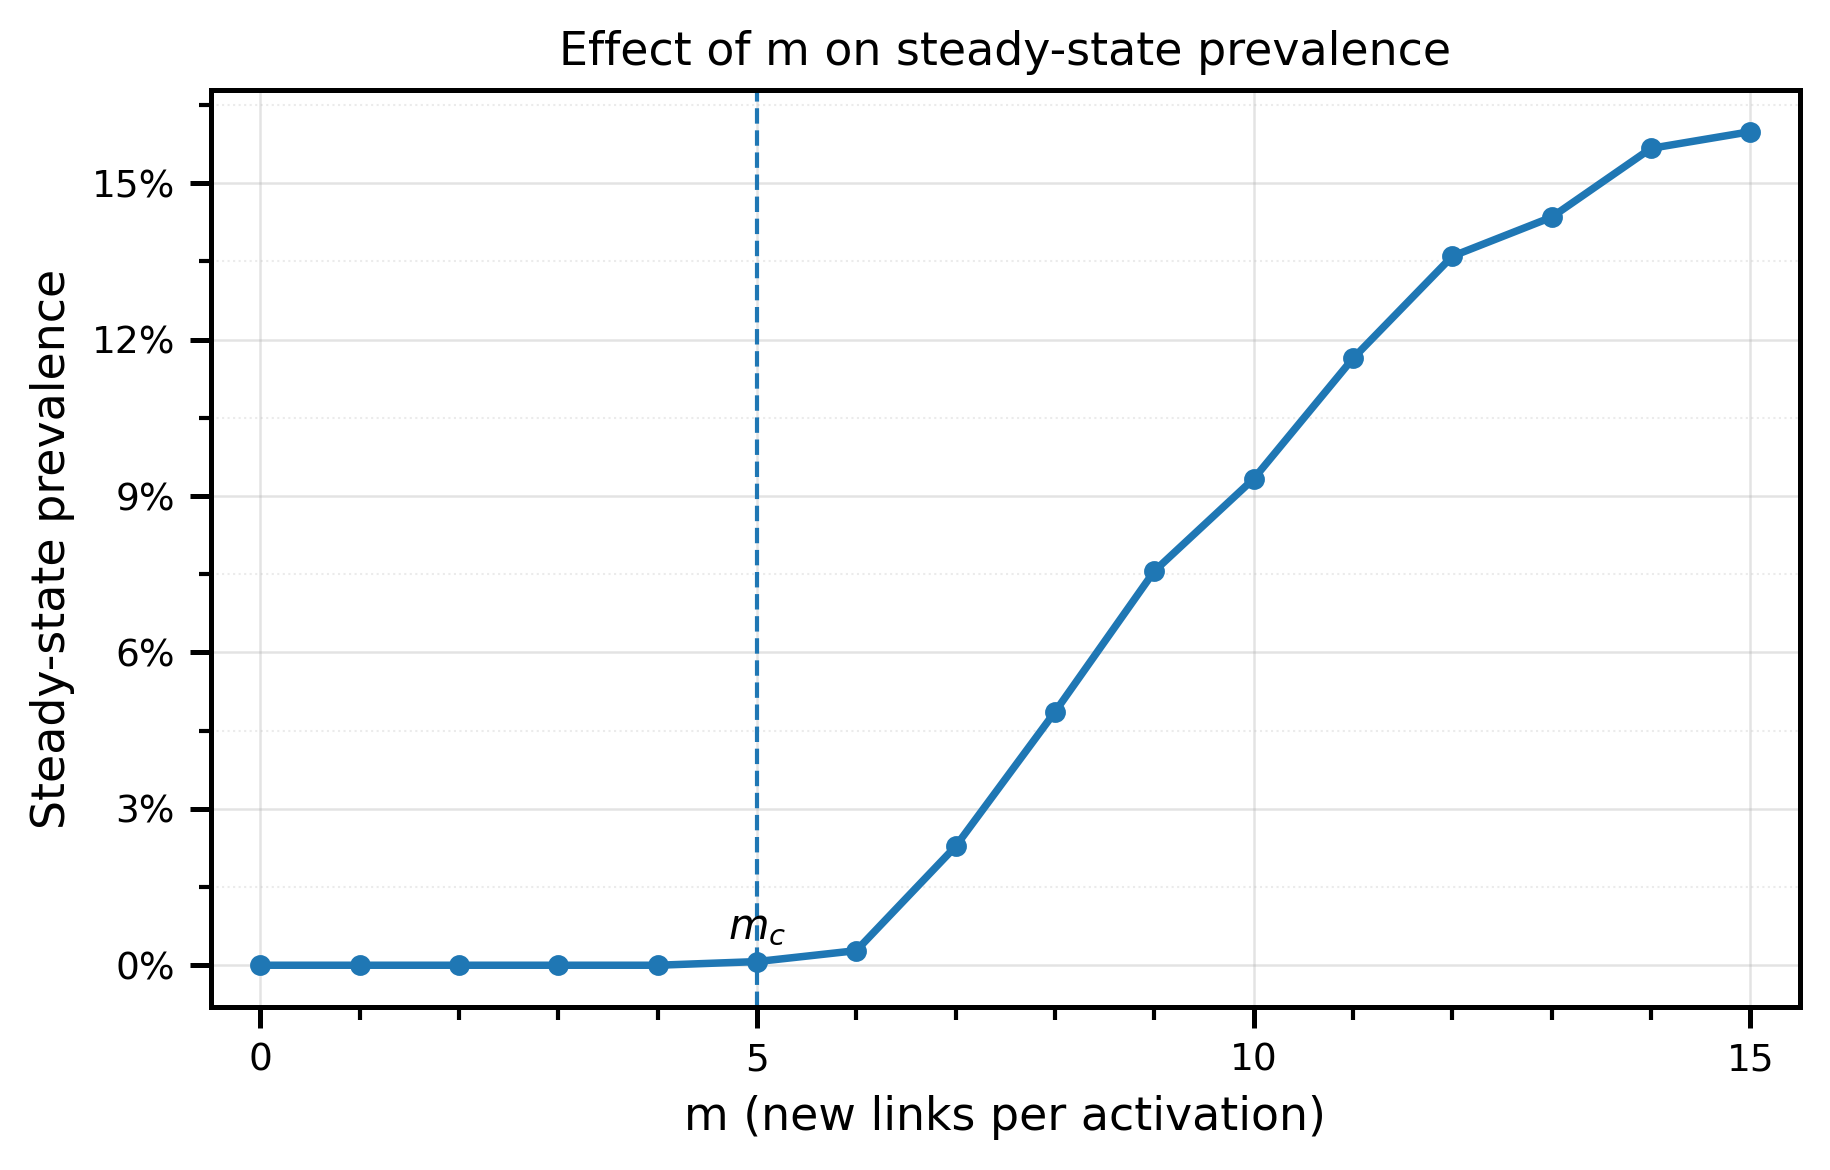

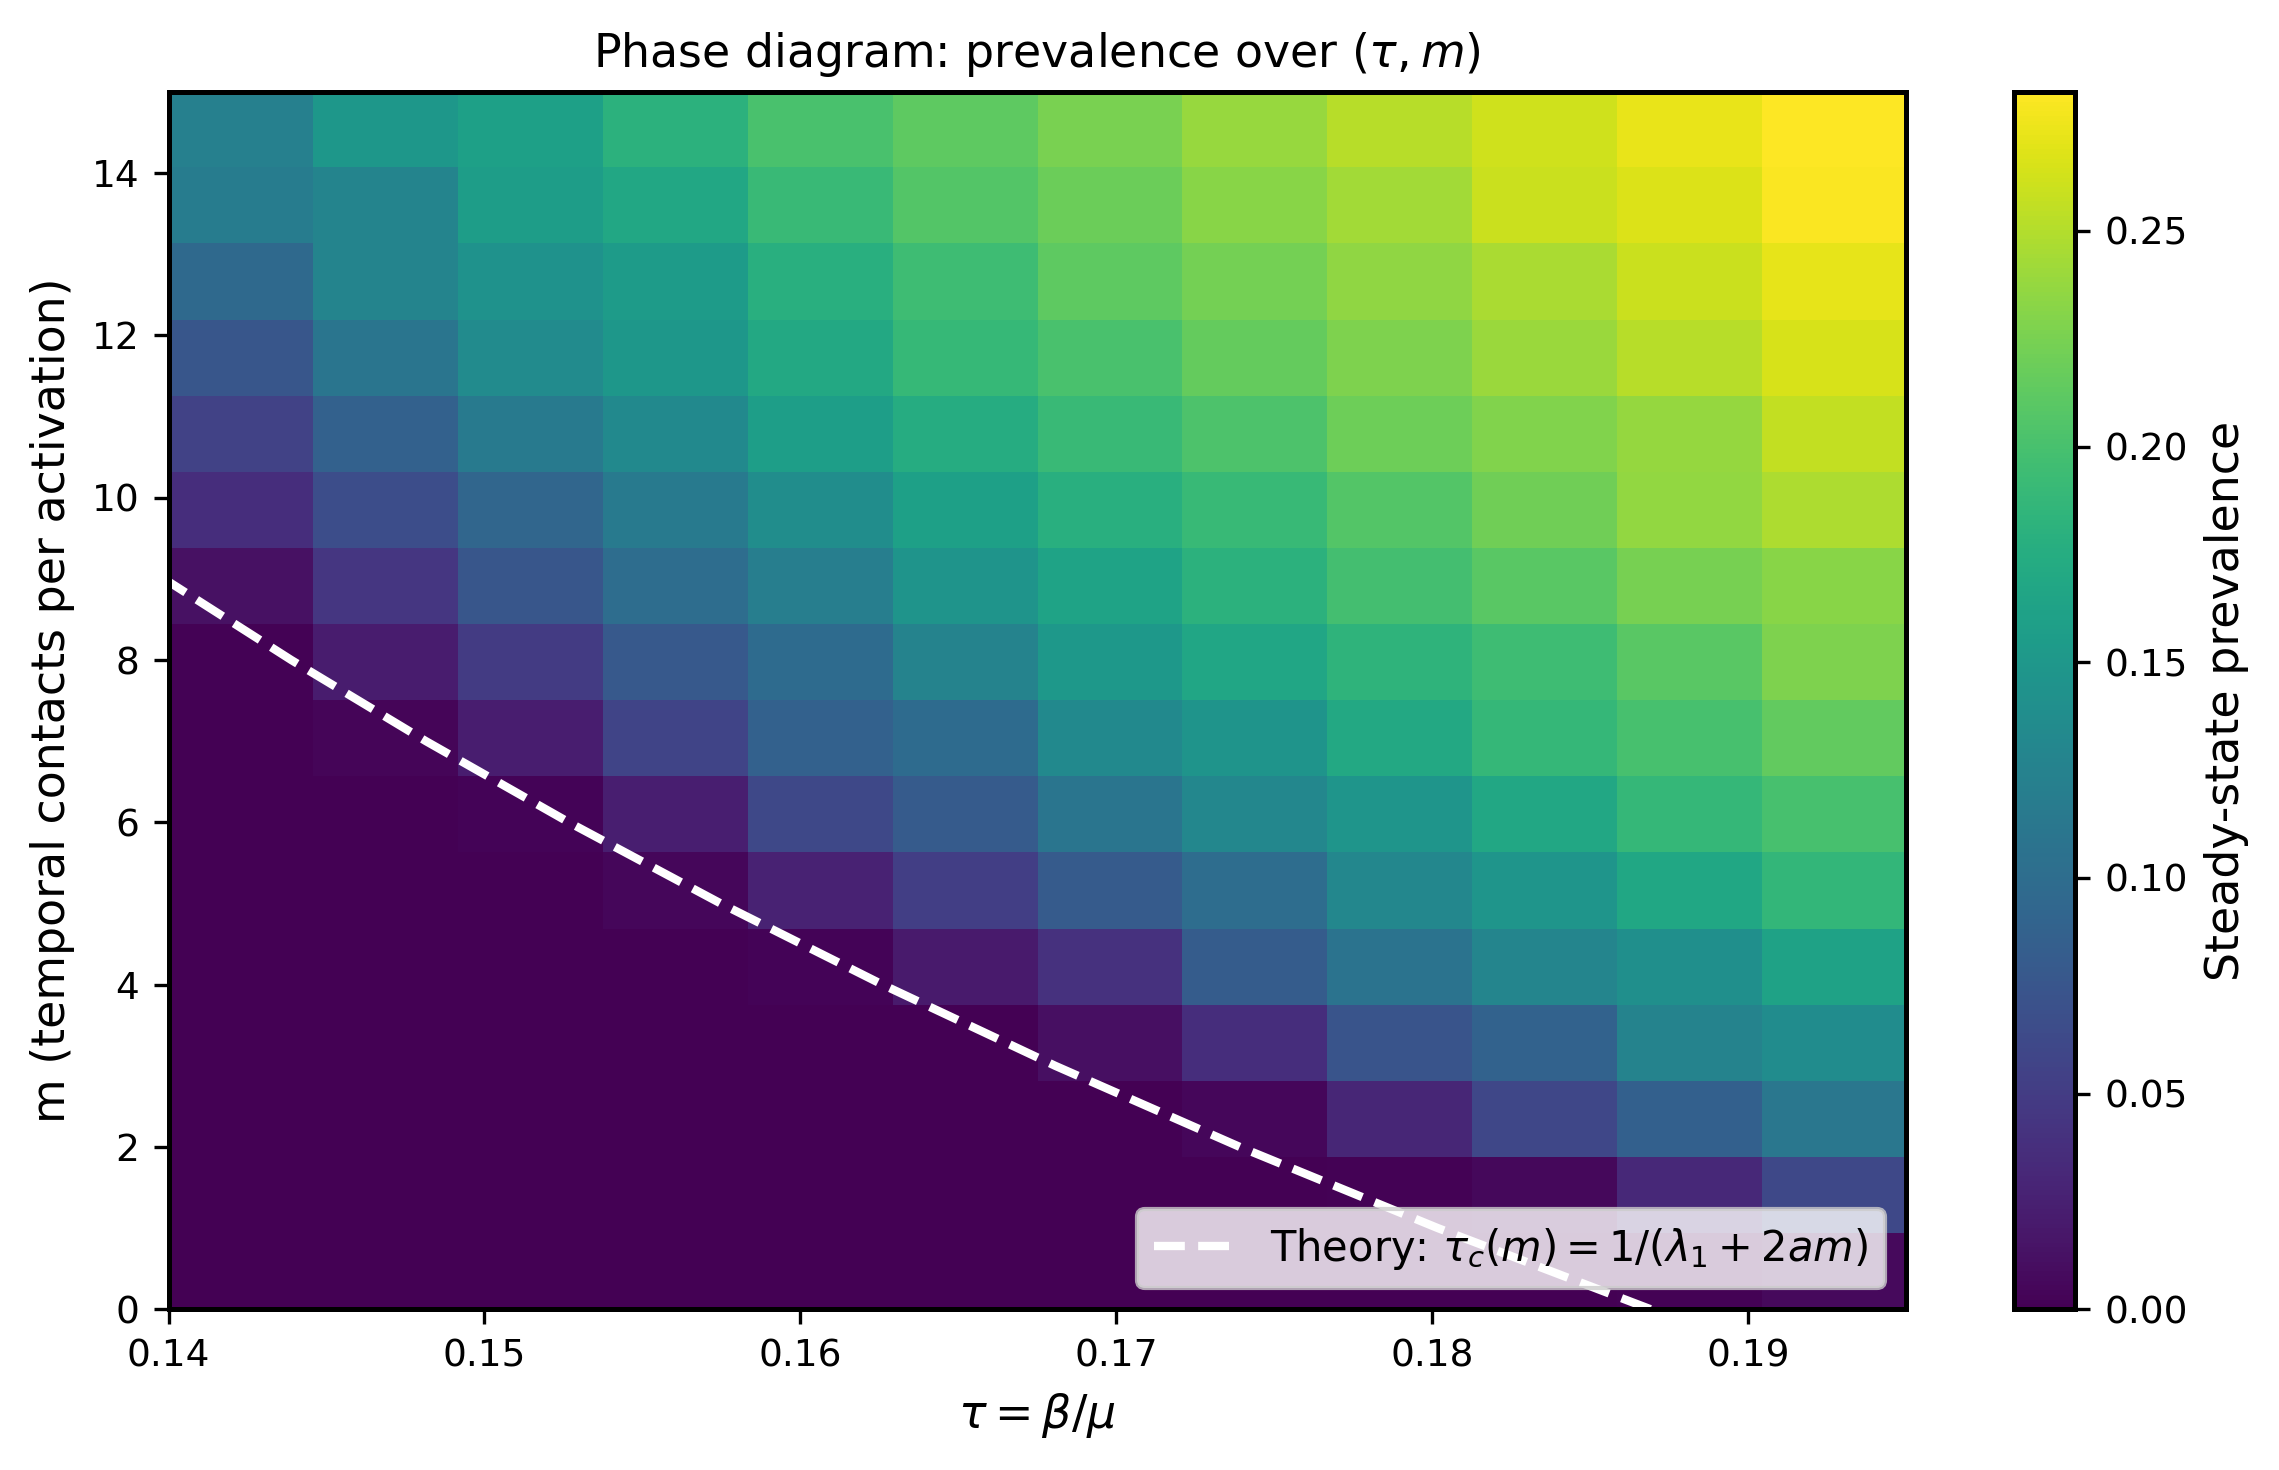

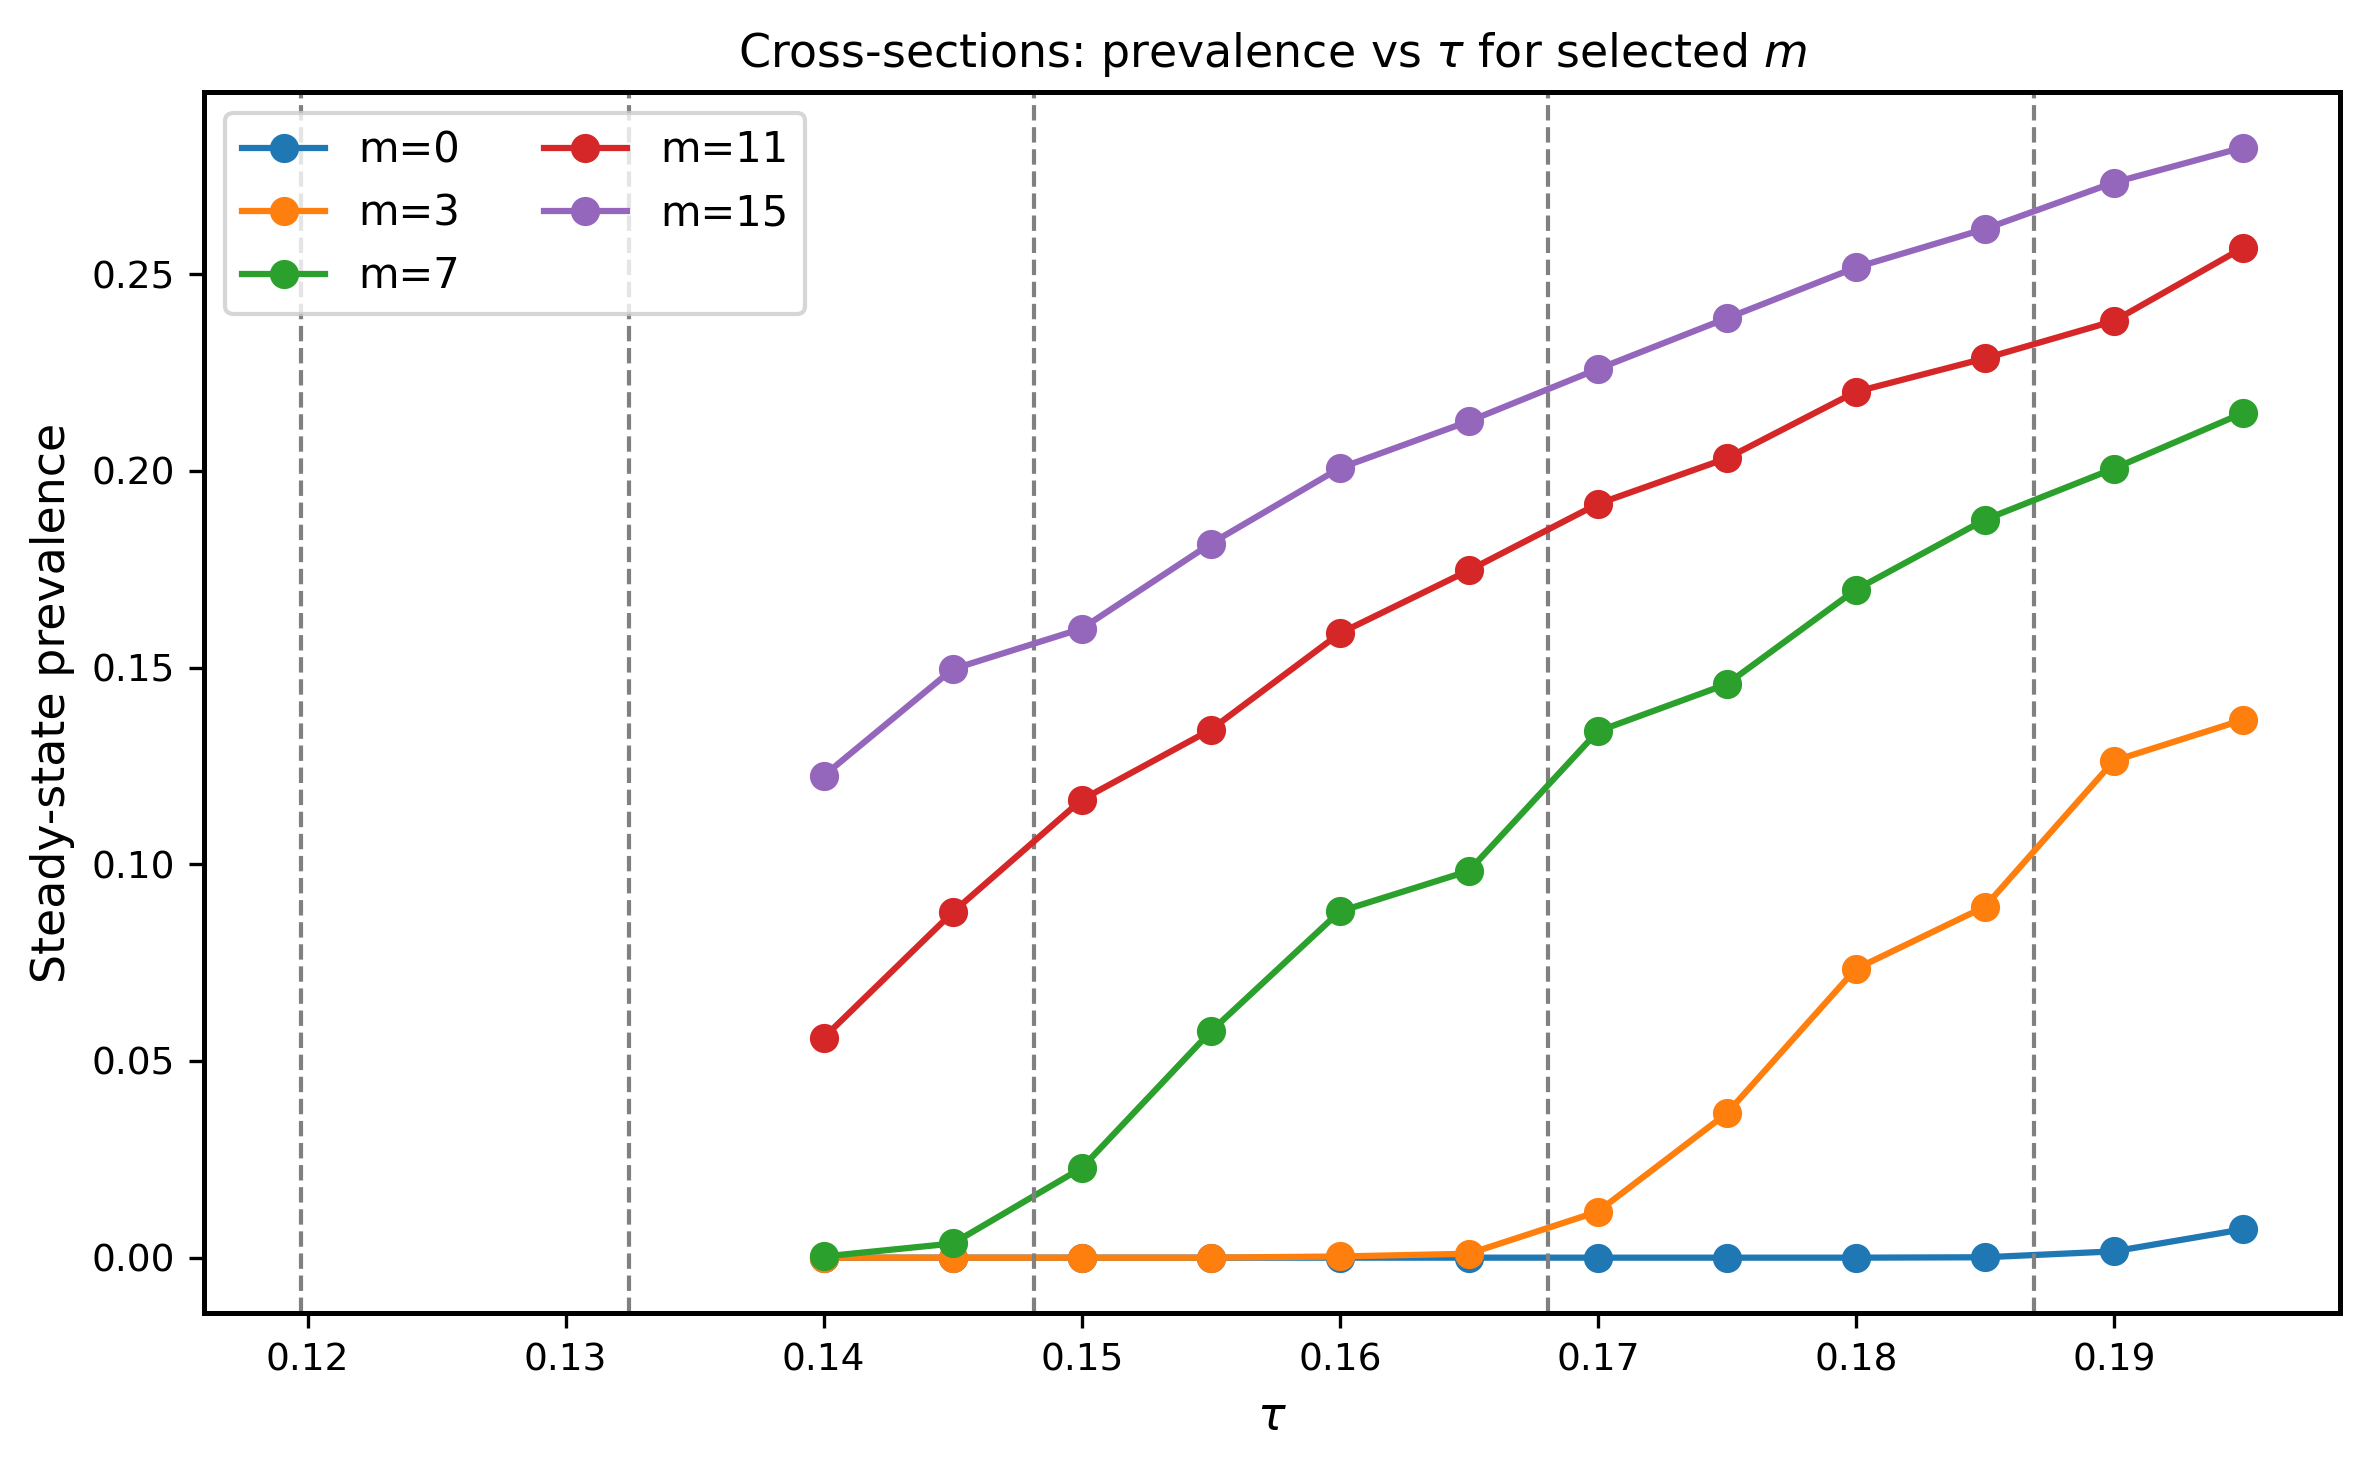

In [39]:
df = pd.read_csv("WS_HM.csv")
m_c = 3 

tau_sweep(df[df['m'] == 3], 0.16)
m_sweep(df[df['beta'] == 0.15], m_c)

HeatMap(df, lambda1=5.35, a=0.1)